# BÀI TẬP CHƯƠNG 3 — DATA PREPROCESSING
## Phân tích tái lập trên dữ liệu Iris

**Dữ liệu chính:** `data/raw/iris.data` — 150 mẫu, 4 đặc trưng, 3 lớp. **Ngày thực hiện:** 30/09/2026. **Ngôn ngữ:** Python; pandas, NumPy, scikit-learn, Matplotlib và seaborn.

Báo cáo đi theo trình tự: lý thuyết và công thức → ví dụ tính thủ công → mã nguồn nguyên khối → kết quả thực thi và diễn giải. Mọi bảng số và hình dưới đây được sinh từ dữ liệu đính kèm, không phải số liệu mô phỏng. Làm tròn chỉ dùng khi trình bày; code luôn tính trên độ chính xác đầy đủ.

### Phạm vi và tính nhất quán dữ liệu

Đề yêu cầu chuẩn hóa tất cả đặc trưng số ở Phần 4, còn yêu cầu bổ sung nhấn mạnh hai đặc trưng tốt nhất. Vì vậy, báo cáo chuẩn hóa cả bốn và dùng cặp petal length–petal width để so sánh hình học. Phân tích dùng toàn bộ dữ liệu cho mục đích mô tả, không báo cáo độ chính xác dự đoán ngoài mẫu.

Hai tệp đính kèm không hoàn toàn giống nhau. Chọn `iris.data` làm nguồn duy nhất cho mọi kết quả; giữ `bezdekIris.data` để đối chiếu, không âm thầm thay thế bằng `load_iris()`. `iris.names` ghi nhận các sai khác với dữ liệu Fisher ở mẫu thứ 35 và 38, tương ứng index 34 và 37. Tệp `Index` chỉ là danh mục lưu trữ, không phải ma trận quan sát. Nguồn gốc bộ dữ liệu được đối chiếu với [UCI Iris](https://archive.ics.uci.edu/dataset/53/iris).

| Sample index | Thuộc tính | iris.data | bezdekIris.data |
|---|---|---:|---:|
|34|petal_width|0.1|0.2|
|37|sepal_width|3.1|3.6|
|37|petal_length|1.5|1.4|

Dùng bản bezdek sẽ cho PCA hai chiều giữ khoảng 95,8132%, khác nhẹ với 95,8010% ở đây. Khác biệt này là do dữ liệu, không phải lỗi tính toán. Các bản dữ liệu gốc đều được bảo toàn trong thư mục `data/raw`.

### Quy ước ký hiệu và độ lệch chuẩn

Gọi $n=150$, $d=4$, $C=3$; $x_{ij}$ là giá trị đặc trưng $j$ của mẫu $i$; $n_c=50$ là số mẫu lớp $c$. Các chỉ số mẫu bắt đầu từ 0. Ký hiệu $s_j$ là Std mẫu (`ddof=1`), còn $\sigma_j$ là Std tính trên tập dữ liệu đang xét với mẫu số $n$ (`ddof=0`):

$$\mu_j=\frac{1}{n}\sum_{i=0}^{n-1}x_{ij},\qquad s_j=\sqrt{\frac{\sum_i(x_{ij}-\mu_j)^2}{n-1}},\qquad \sigma_j=\sqrt{\frac{\sum_i(x_{ij}-\mu_j)^2}{n}}.$$

Do đó $\sigma_j=s_j\sqrt{(n-1)/n}$. Bảng mô tả hiển thị cả hai. StandardScaler và phần chuẩn hóa dùng $\sigma_j$; thống kê `pandas.std()` mặc định dùng $s_j$. Phân biệt này là điều kiện để tính tay khớp với code.

# PHẦN 1 — UNDERSTANDING DATA
## Bước 1. Lý thuyết và công thức

Một sample là một bông hoa được đo; feature là một thuộc tính đo lường; label là loài hoa. Ta biểu diễn $X\in\mathbb{R}^{150\times4}$ và $y\in\{\mathrm{setosa},\mathrm{versicolor},\mathrm{virginica}\}^{150}$. Mỗi record $(\mathbf{x}_i,y_i)$ gồm bốn giá trị đầu vào và một nhãn. Tệp training_set.csv chứa đầy đủ 150 record, nhưng tên tệp không hàm ý đã chia train/test.

| Thuộc tính | Ý nghĩa | Data type khi đọc bằng pandas | Attribute type | Thang đo | Đơn vị |
|---|---|---|---|---|---|
|sepal_length|Chiều dài đài hoa|float64|Định lượng, liên tục|Ratio|cm|
|sepal_width|Chiều rộng đài hoa|float64|Định lượng, liên tục|Ratio|cm|
|petal_length|Chiều dài cánh hoa|float64|Định lượng, liên tục|Ratio|cm|
|petal_width|Chiều rộng cánh hoa|float64|Định lượng, liên tục|Ratio|cm|
|species|Loài hoa|Chuỗi; object hoặc str tùy phiên bản pandas|Định tính, nominal|Không có thứ tự|Không có|

Dữ liệu đo được ghi đến một chữ số thập phân nhưng đại lượng vật lý vẫn là liên tục. Nếu mã hóa loài thành 0, 1, 2, các số đó chỉ là mã danh mục, không phải số đo để lấy trung bình hay tính Pearson với nhãn. Mỗi lớp có 50 mẫu (33,33%); không có giá trị thiếu. Không xóa các record trùng số đo: nhiều bông hoa có thể cùng kết quả làm tròn.

Hệ số Pearson của hai đặc trưng $a,b$ đo mức độ liên hệ tuyến tính:

$$r_{ab}=\frac{\sum_i(x_{ia}-\mu_a)(x_{ib}-\mu_b)}{\sqrt{\sum_i(x_{ia}-\mu_a)^2\sum_i(x_{ib}-\mu_b)^2}}.$$

$r\in[-1,1]$; dấu cho biết chiều liên hệ, độ lớn cho biết độ mạnh tuyến tính. Tương quan không chứng minh nhân quả, và $r\approx0$ không đồng nghĩa độc lập. Min và Max là hai giá trị biên của mẫu quan sát; Mean mô tả vị trí, Std mô tả độ phân tán theo cùng đơn vị cm.

## Bước 2. Ví dụ tính thủ công

Mẫu đầu tiên là $\mathbf{x}_0=(5.1,3.5,1.4,0.2)$, $y_0=\mathrm{Iris\!\!\!-setosa}$. Với sepal length, tổng 150 giá trị là 876,5 và tổng bình phương độ lệch là 102,168333:

$$\mu_{SL}=\frac{876.5}{150}=5.843333,\qquad s_{SL}=\sqrt{\frac{102.168333}{149}}=0.828066.$$

$$x_{0,SL}-\mu_{SL}=5.1-5.843333=-0.743333,\qquad (x_{0,SL}-\mu_{SL})^2=0.552544.$$

Như vậy mẫu 0 đóng góp 0,552544 vào tổng bình phương; không thể suy ra Std của cả tập chỉ từ một mẫu. Tương tự, với petal length (PL) và petal width (PW):

$$x_{0,PL}-\mu_{PL}=1.4-3.758667=-2.358667,$$
$$x_{0,PW}-\mu_{PW}=0.2-1.198667=-0.998667,$$
$$(x_{0,PL}-\mu_{PL})(x_{0,PW}-\mu_{PW})=2.355522.$$

Cộng các đóng góp của đủ 150 mẫu, ta có $S_{PL,PW}=193.161733$, $S_{PL,PL}=463.863733$, $S_{PW,PW}=86.779733$:

$$r_{PL,PW}=\frac{193.161733}{\sqrt{463.863733\times86.779733}}=0.962757.$$

Đây là tính Pearson toàn tập, với mẫu 0 được chỉ rõ như một hạng tử; không gán một hệ số tương quan cho riêng bông hoa đầu tiên.

## Bước 3. Mã Python chạy độc lập

Chạy `python src/part1.py` từ thư mục dự án sau khi cài requirements. Các phần sau cũng tự đọc dữ liệu và có đầy đủ import, không phụ thuộc biến đã chạy ở phần trước.



In [2]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Chạy từ file .py hoặc cell Jupyter trong thư mục dự án.
if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data/raw/iris.data").exists())
FIG = ROOT / "figures"
TAB = ROOT / "tables"
FIG.mkdir(exist_ok=True)
TAB.mkdir(exist_ok=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df = pd.read_csv(ROOT / "data/raw/iris.data", header=None,
                 names=FEATURES + ["species"])
X, y = df[FEATURES].astype(float), df["species"]
assert X.shape == (150, 4) and not df.isna().any().any()
assert y.value_counts().eq(50).all()
CLASSES = sorted(y.unique())
COLORS = ["#008c95", "#e58c25", "#7957ae"]
MARKERS = ["o", "s", "^"]
sns.set_theme(style="whitegrid", font_scale=1.05)

def save_table(frame, name):
    frame.to_csv(TAB / (name + ".csv"), encoding="utf-8-sig")
    print("\n" + name + "\n" + frame.round(6).to_string())

def save_fig(fig, name):
    fig.savefig(FIG / (name + ".png"), dpi=170, bbox_inches="tight")
    plt.close(fig)

def scatter(ax, data, a, b, unit="cm"):
    for cls, color, marker in zip(CLASSES, COLORS, MARKERS):
        m = y == cls
        ax.scatter(data.loc[m, a], data.loc[m, b], c=color, marker=marker,
                   label=cls.replace("Iris-", ""), alpha=.8, s=32)
    suffix = f" ({unit})" if unit else ""
    ax.set(xlabel=a + suffix, ylabel=b + suffix)
    ax.legend(fontsize=8)

# PHẦN 1: mô tả, thống kê và tương quan.
save_table(df.rename_axis("sample_index"), "training_set")
save_table(X, "X")
save_table(y.to_frame(), "y")
stats = X.agg(["min", "max", "mean", "std"]).T.rename(columns={"std":"std_ddof1"})
stats["std_ddof0"] = X.std(ddof=0)
save_table(stats, "descriptive_statistics")
save_table(X.corr(method="pearson"), "pearson")
save_table(df.groupby("species")[FEATURES].mean(), "class_means")
save_table(df.groupby("species")[FEATURES].var(ddof=0), "class_variances_ddof0")
g = sns.pairplot(df, hue="species", palette=COLORS, diag_kind="hist", markers=MARKERS)
g.fig.suptitle("Iris: feature pairs and marginal distributions (cm)", y=1.02)
save_fig(g.fig, "01_pairplot")
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, fmt=".4f", vmin=-1, vmax=1, cmap="vlag", ax=ax)
ax.set_title("Pearson correlation | iris.data | n=150")
save_fig(fig, "02_pearson_heatmap")
# Kiểm tra phiên bản, không tự động thay thế các giá trị gốc.
other = pd.read_csv(ROOT / "data/raw/bezdekIris.data", header=None, names=df.columns)
mask = (df != other).any(axis=1)
save_table(pd.concat({"iris.data":df[mask], "bezdekIris.data":other[mask]}), "data_version_differences")



training_set
              sepal_length  sepal_width  petal_length  petal_width          species
sample_index                                                                       
0                      5.1          3.5           1.4          0.2      Iris-setosa
1                      4.9          3.0           1.4          0.2      Iris-setosa
2                      4.7          3.2           1.3          0.2      Iris-setosa
3                      4.6          3.1           1.5          0.2      Iris-setosa
4                      5.0          3.6           1.4          0.2      Iris-setosa
5                      5.4          3.9           1.7          0.4      Iris-setosa
6                      4.6          3.4           1.4          0.3      Iris-setosa
7                      5.0          3.4           1.5          0.2      Iris-setosa
8                      4.4          2.9           1.4          0.2      Iris-setosa
9                      4.9          3.1           1.5         



## Bước 4. Kết quả, trực quan hóa và nhận xét

Năm record đầu của bảng $(X,y)$:

| sample_index | sepal_length | sepal_width | petal_length | petal_width | species |
|---|---|---|---|---|---|
| 0 | 5.100000 | 3.500000 | 1.400000 | 0.200000 | Iris-setosa |
| 1 | 4.900000 | 3.000000 | 1.400000 | 0.200000 | Iris-setosa |
| 2 | 4.700000 | 3.200000 | 1.300000 | 0.200000 | Iris-setosa |
| 3 | 4.600000 | 3.100000 | 1.500000 | 0.200000 | Iris-setosa |
| 4 | 5.000000 | 3.600000 | 1.400000 | 0.200000 | Iris-setosa |

Thống kê đặc trưng (cm):

| Index | min | max | mean | std_ddof1 | std_ddof0 |
|---|---|---|---|---|---|
| sepal_length | 4.300000 | 7.900000 | 5.843333 | 0.828066 | 0.825301 |
| sepal_width | 2.000000 | 4.400000 | 3.054000 | 0.433594 | 0.432147 |
| petal_length | 1.000000 | 6.900000 | 3.758667 | 1.764420 | 1.758529 |
| petal_width | 0.100000 | 2.500000 | 1.198667 | 0.763161 | 0.760613 |

Ma trận Pearson:

| Index | sepal_length | sepal_width | petal_length | petal_width |
|---|---|---|---|---|
| sepal_length | 1.000000 | -0.109369 | 0.871754 | 0.817954 |
| sepal_width | -0.109369 | 1.000000 | -0.420516 | -0.356544 |
| petal_length | 0.871754 | -0.420516 | 1.000000 | 0.962757 |
| petal_width | 0.817954 | -0.356544 | 0.962757 | 1.000000 |
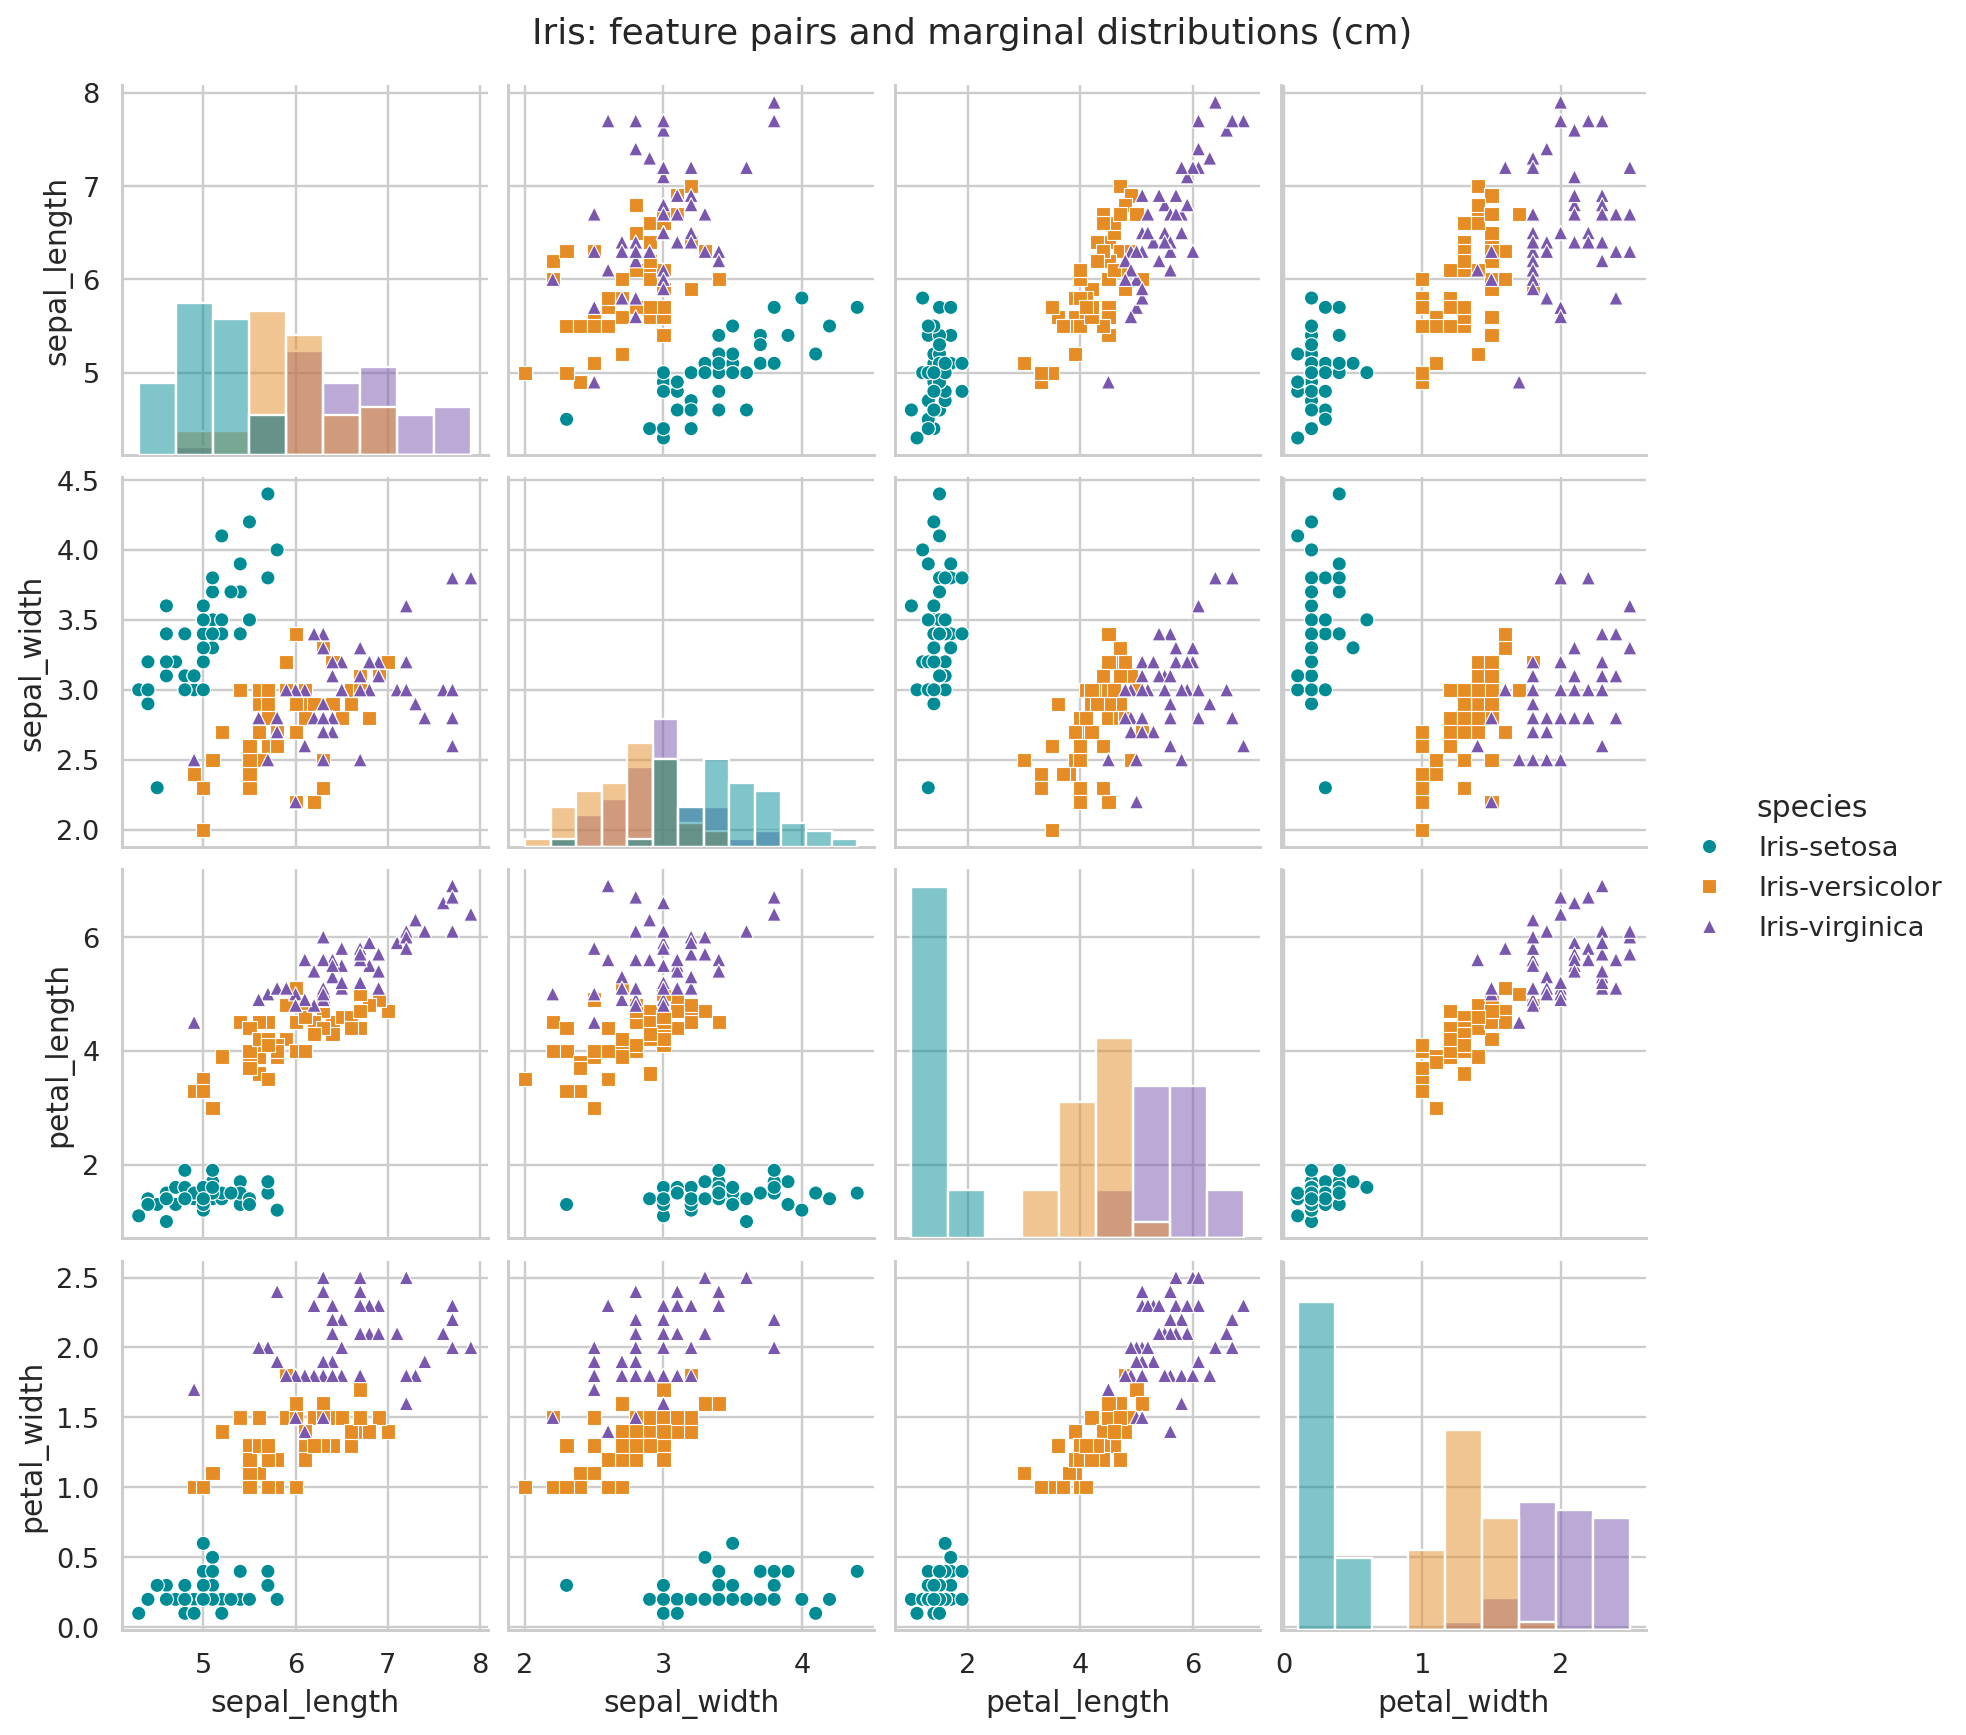

*Hình 1. Pairplot: màu và marker phân biệt ba loài; đường chéo là histogram.*

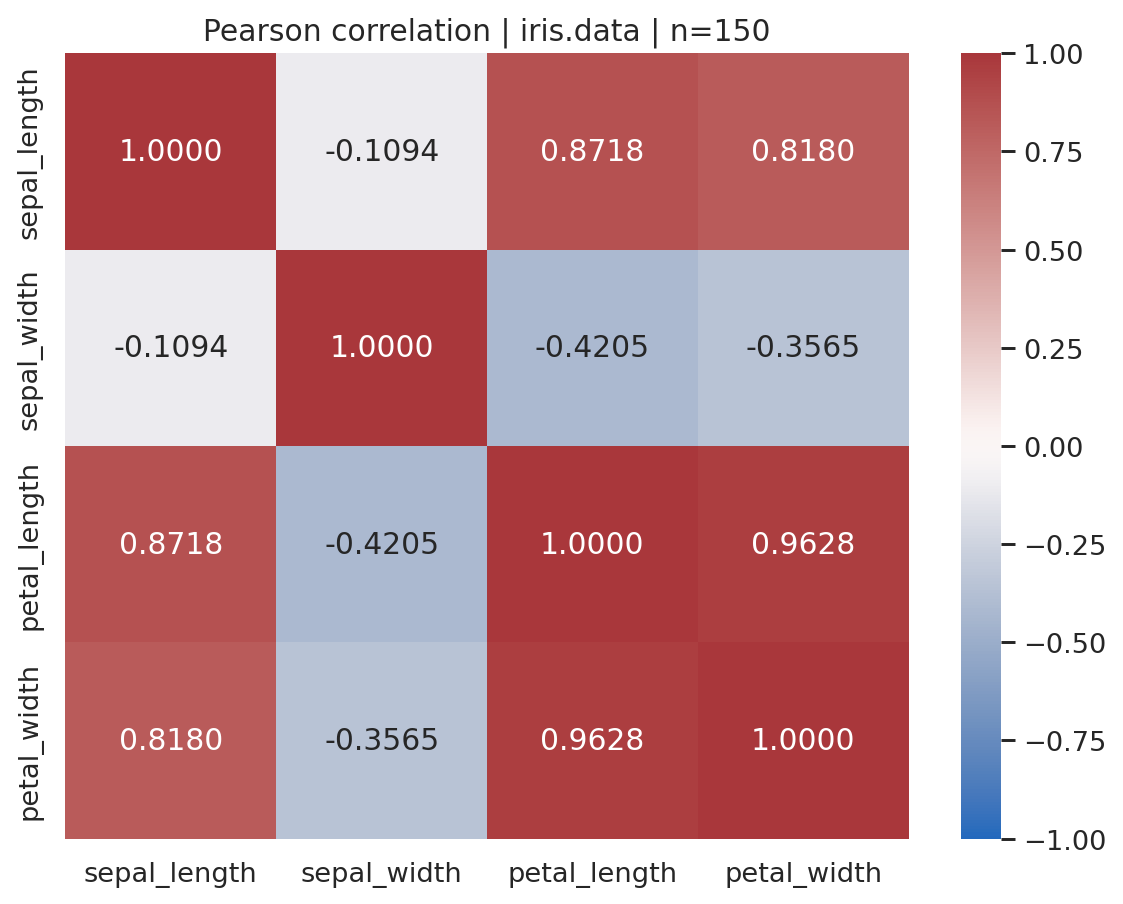

*Hình 2. Ma trận Pearson, tính trên 150 mẫu iris.data.*

Petal length có range 5,9 cm, lớn nhất trong bốn thuộc tính; Std mẫu 1,7644 cm cũng lớn nhất. Sepal width có Std mẫu 0,4336 cm, nhỏ nhất. Phân tán toàn tập vừa phản ánh biến thiên trong lớp vừa phản ánh khoảng cách giữa các lớp; không thể xem toàn bộ Std cao là nhiễu.

Hai đặc trưng petal có tương quan dương rất mạnh (0,9628). Sepal length cũng tương quan mạnh với petal length (0,8718) và petal width (0,8180). Đây là dấu hiệu dư thừa tuyến tính và nguy cơ đa cộng tuyến khi dùng đồng thời trong mô hình tuyến tính; ma trận tương quan là bước sàng lọc, không phải phép chẩn đoán đầy đủ độ ổn định của mọi mô hình. Sepal width gần không tương quan tuyến tính với sepal length trên toàn tập (-0,1094), nhưng điều đó không loại trừ cấu trúc riêng trong từng lớp.

Pairplot cho thấy setosa có cánh hoa ngắn và hẹp, tách khá rõ. Versicolor và virginica còn chồng lấn. Tương quan toàn tập mạnh một phần do tâm ba lớp xếp theo hướng tăng kích thước cánh hoa; không được diễn giải nó như một quan hệ sinh học đồng nhất bên trong mọi lớp.



# PHẦN 2 — FEATURE SELECTION
## Bước 1. Lý thuyết và công thức

Feature selection giữ nguyên các cột ban đầu, tìm tập con có khả năng biểu diễn hoặc phân biệt lớp tốt. Với bốn đặc trưng, số cặp là $\binom42=6$ và số bộ ba là $\binom43=4$. Trực quan hóa dùng cả màu và marker để kiểm tra độ tách lớp, độ gọn của cụm và miền chồng lấn.

Fisher Score đa lớp cho từng đặc trưng $j$ được định nghĩa nhất quán như sau:

$$\mu_{cj}=\frac{1}{n_c}\sum_{i:y_i=c}x_{ij},\qquad \sigma_{cj}^2=\frac{1}{n_c}\sum_{i:y_i=c}(x_{ij}-\mu_{cj})^2,$$
$$B_j=\sum_{c=1}^{C}n_c(\mu_{cj}-\mu_j)^2,\qquad W_j=\sum_{c=1}^{C}n_c\sigma_{cj}^2,$$
$$F_j=\frac{B_j}{W_j}.$$

Điểm lớn khi tâm lớp xa nhau và biến thiên nội lớp nhỏ. Cả tử và mẫu có đơn vị cm² nên tỷ số không có đơn vị. Đây là chỉ tiêu có giám sát, vì cần nhãn để tính tâm lớp. Trường hợp mẫu số bằng 0 cần xử lý riêng; dữ liệu này có $W_j>0$ ở cả bốn đặc trưng.

Không nhầm Fisher $B/W$ với thống kê ANOVA do `f_classif` trả về:

$$F_j^{ANOVA}=\frac{B_j/(C-1)}{W_j/(n-C)}=\frac{147}{2}F_j=73.5F_j.$$

Hai định nghĩa tạo cùng thứ hạng trên bộ dữ liệu này nhưng giá trị số khác nhau. Bảng kết quả ghi rõ cả hai để tránh đối chiếu sai.

## Bước 2. Ví dụ tính thủ công

Dùng petal length. Trung bình ba lớp lần lượt là 1,464; 4,260; 5,552 và trung bình toàn tập là 3,758667. Phương sai nội lớp với mẫu số 50 lần lượt là 0,029504; 0,216400; 0,298496.

Mẫu 0 thuộc setosa, nên đóng góp vào $W_{PL}$ là:

$$(x_{0,PL}-\mu_{setosa,PL})^2=(1.4-1.464)^2=(-0.064)^2=0.004096.$$

Cộng đủ các đóng góp trong từng lớp và giữa các lớp:

$$W_{PL}=50(0.029504+0.216400+0.298496)=27.220000,$$
$$B_{PL}=50[(1.464-3.758667)^2+(4.260-3.758667)^2+(5.552-3.758667)^2]=436.643733,$$
$$F_{PL}=436.643733/27.220000=16.041283.$$

Như Pearson, Fisher là chỉ tiêu toàn tập; mẫu 0 minh họa một đóng góp chứ không đủ để ước lượng điểm Fisher. Giá trị ANOVA tương ứng là $16.041283\times73.5=1179.034328$ khi tính bằng số chưa làm tròn.

## Bước 3. Mã Python chạy độc lập



In [3]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Chạy từ file .py hoặc cell Jupyter trong thư mục dự án.
if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data/raw/iris.data").exists())
FIG = ROOT / "figures"
TAB = ROOT / "tables"
FIG.mkdir(exist_ok=True)
TAB.mkdir(exist_ok=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df = pd.read_csv(ROOT / "data/raw/iris.data", header=None,
                 names=FEATURES + ["species"])
X, y = df[FEATURES].astype(float), df["species"]
assert X.shape == (150, 4) and not df.isna().any().any()
assert y.value_counts().eq(50).all()
CLASSES = sorted(y.unique())
COLORS = ["#008c95", "#e58c25", "#7957ae"]
MARKERS = ["o", "s", "^"]
sns.set_theme(style="whitegrid", font_scale=1.05)

def save_table(frame, name):
    frame.to_csv(TAB / (name + ".csv"), encoding="utf-8-sig")
    print("\n" + name + "\n" + frame.round(6).to_string())

def save_fig(fig, name):
    fig.savefig(FIG / (name + ".png"), dpi=170, bbox_inches="tight")
    plt.close(fig)

def scatter(ax, data, a, b, unit="cm"):
    for cls, color, marker in zip(CLASSES, COLORS, MARKERS):
        m = y == cls
        ax.scatter(data.loc[m, a], data.loc[m, b], c=color, marker=marker,
                   label=cls.replace("Iris-", ""), alpha=.8, s=32)
    suffix = f" ({unit})" if unit else ""
    ax.set(xlabel=a + suffix, ylabel=b + suffix)
    ax.legend(fontsize=8)

# PHẦN 2: đủ C(4,2)=6 cặp và C(4,3)=4 bộ ba.
fig, axes = plt.subplots(2,3, figsize=(17,10))
for ax, (a,b) in zip(axes.flat, combinations(FEATURES,2)):
    scatter(ax,X,a,b)
    ax.set_title(a + " vs " + b)
fig.tight_layout()
save_fig(fig,"03_all_2d_pairs")
fig = plt.figure(figsize=(16,13))
for i,(a,b,c) in enumerate(combinations(FEATURES,3),1):
    ax = fig.add_subplot(2,2,i, projection="3d")
    for cls,color,marker in zip(CLASSES,COLORS,MARKERS):
        m=y==cls
        ax.scatter(X.loc[m,a],X.loc[m,b],X.loc[m,c],color=color,marker=marker,
                   label=cls.replace("Iris-",""),alpha=.8,s=24)
    ax.set(xlabel=a+" (cm)",ylabel=b+" (cm)",zlabel=c+" (cm)", title=f"Combination {i}: {a}, {b}, {c}")
    ax.view_init(elev=24,azim=40)
    ax.legend(fontsize=8)
fig.subplots_adjust(wspace=.12,hspace=.2)
save_fig(fig,"04_all_3d_triples")
# Fisher đa lớp: tổng bình phương giữa lớp / trong lớp.
# Phương sai từng lớp dùng ddof=0 để n_c * var_c đúng bằng SS trong lớp.
mu = X.mean()
B = sum((y==c).sum() * (X[y==c].mean()-mu)**2 for c in CLASSES)
W = sum(((X[y==c]-X[y==c].mean())**2).sum() for c in CLASSES)
fisher = pd.DataFrame({"between_SS":B,"within_SS":W,"Fisher_B_over_W":B/W})
fisher["ANOVA_F"] = (B/(len(CLASSES)-1))/(W/(len(X)-len(CLASSES)))
fisher = fisher.sort_values("Fisher_B_over_W",ascending=False)
save_table(fisher,"fisher_scores")
fig,ax = plt.subplots(figsize=(9,5))
ax.bar(fisher.index,fisher.Fisher_B_over_W,color=["#008c95","#32b4b2","#e58c25","#7957ae"])
for i,v in enumerate(fisher.Fisher_B_over_W): ax.text(i,v+.1,f"{v:.4f}",ha="center")
ax.set(xlabel="Feature",ylabel="Fisher score B/W",title="Supervised univariate feature ranking")
save_fig(fig,"05_fisher_ranking")



fisher_scores
              between_SS  within_SS  Fisher_B_over_W      ANOVA_F
petal_length  436.643733    27.2200        16.041283  1179.034328
petal_width    80.604133     6.1756        13.052033   959.324406
sepal_length   63.212133    38.9562         1.622646   119.264502
sepal_width    10.977600    17.0350         0.644414    47.364461




## Bước 4. Kết quả, trực quan hóa và nhận xét

Trung bình theo lớp:

| species | sepal_length | sepal_width | petal_length | petal_width |
|---|---|---|---|---|
| Iris-setosa | 5.006000 | 3.418000 | 1.464000 | 0.244000 |
| Iris-versicolor | 5.936000 | 2.770000 | 4.260000 | 1.326000 |
| Iris-virginica | 6.588000 | 2.974000 | 5.552000 | 2.026000 |

Phương sai nội lớp (`ddof=0`):

| species | sepal_length | sepal_width | petal_length | petal_width |
|---|---|---|---|---|
| Iris-setosa | 0.121764 | 0.142276 | 0.029504 | 0.011264 |
| Iris-versicolor | 0.261104 | 0.096500 | 0.216400 | 0.038324 |
| Iris-virginica | 0.396256 | 0.101924 | 0.298496 | 0.073924 |

Xếp hạng Fisher:

| Index | between_SS | within_SS | Fisher_B_over_W | ANOVA_F |
|---|---|---|---|---|
| petal_length | 436.643733 | 27.220000 | 16.041283 | 1179.034328 |
| petal_width | 80.604133 | 6.175600 | 13.052033 | 959.324406 |
| sepal_length | 63.212133 | 38.956200 | 1.622646 | 119.264502 |
| sepal_width | 10.977600 | 17.035000 | 0.644414 | 47.364461 |
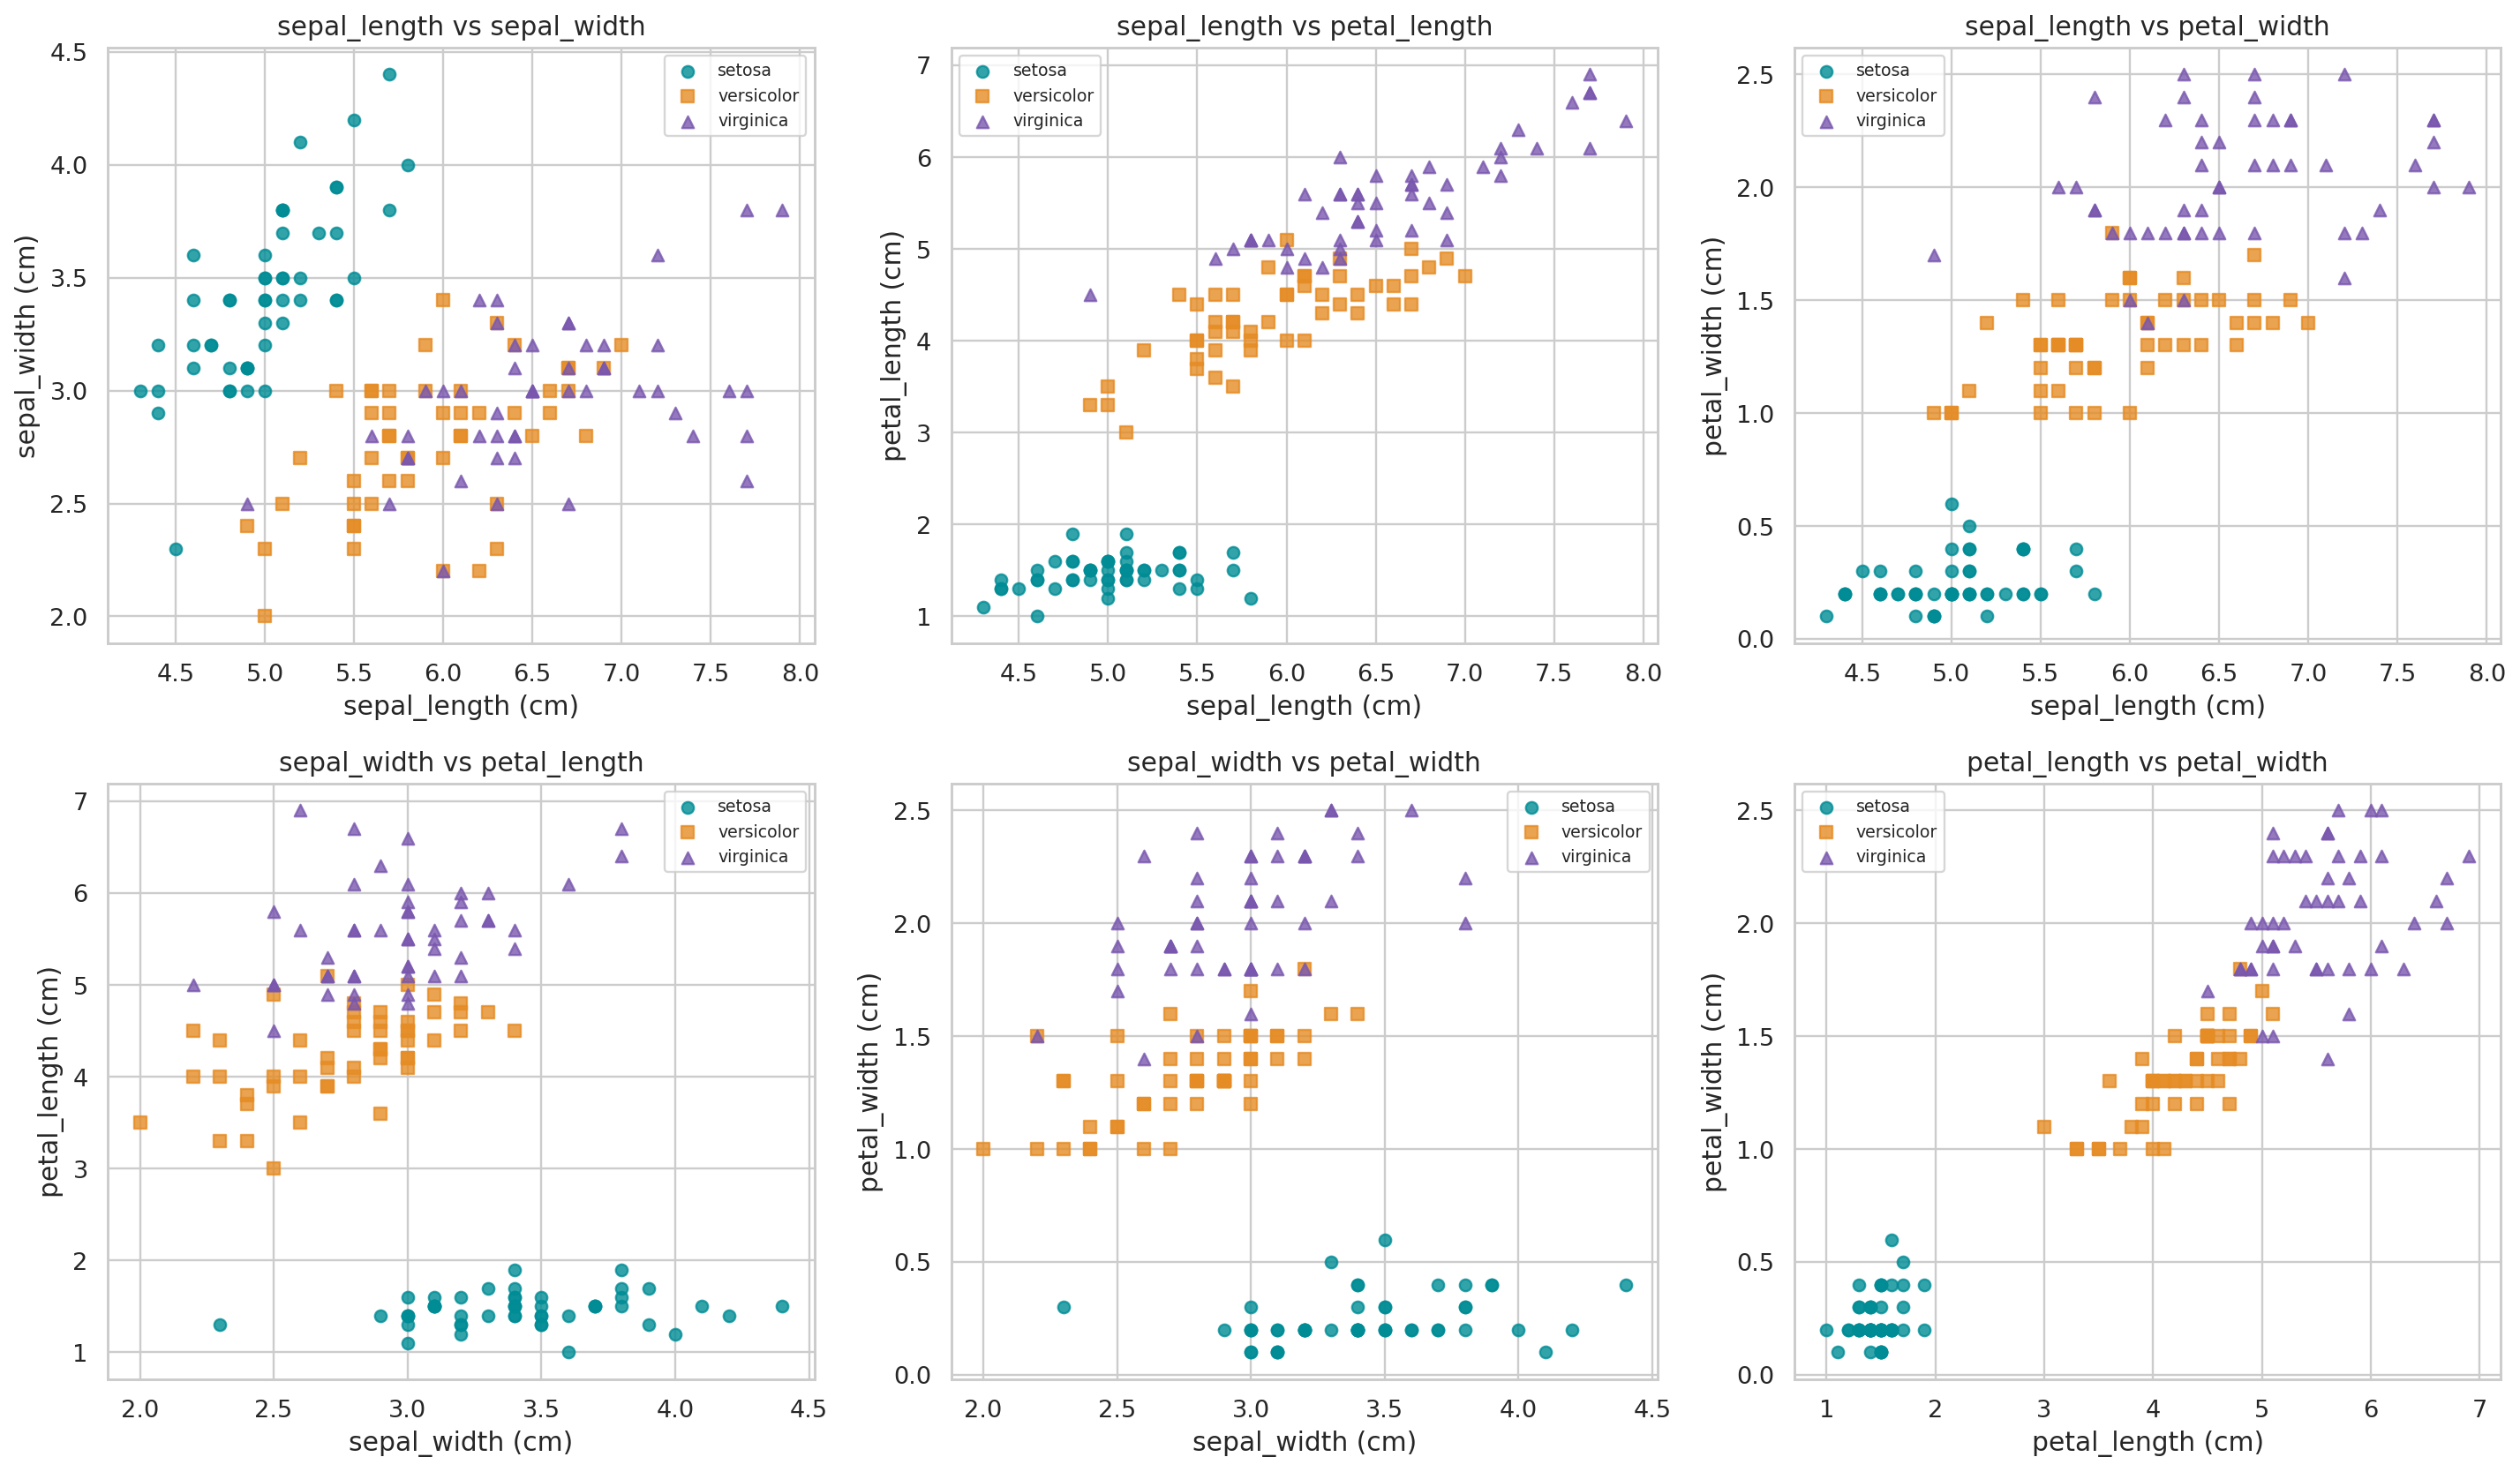

*Hình 3. Đủ sáu tổ hợp hai chiều; trục đo bằng cm.*

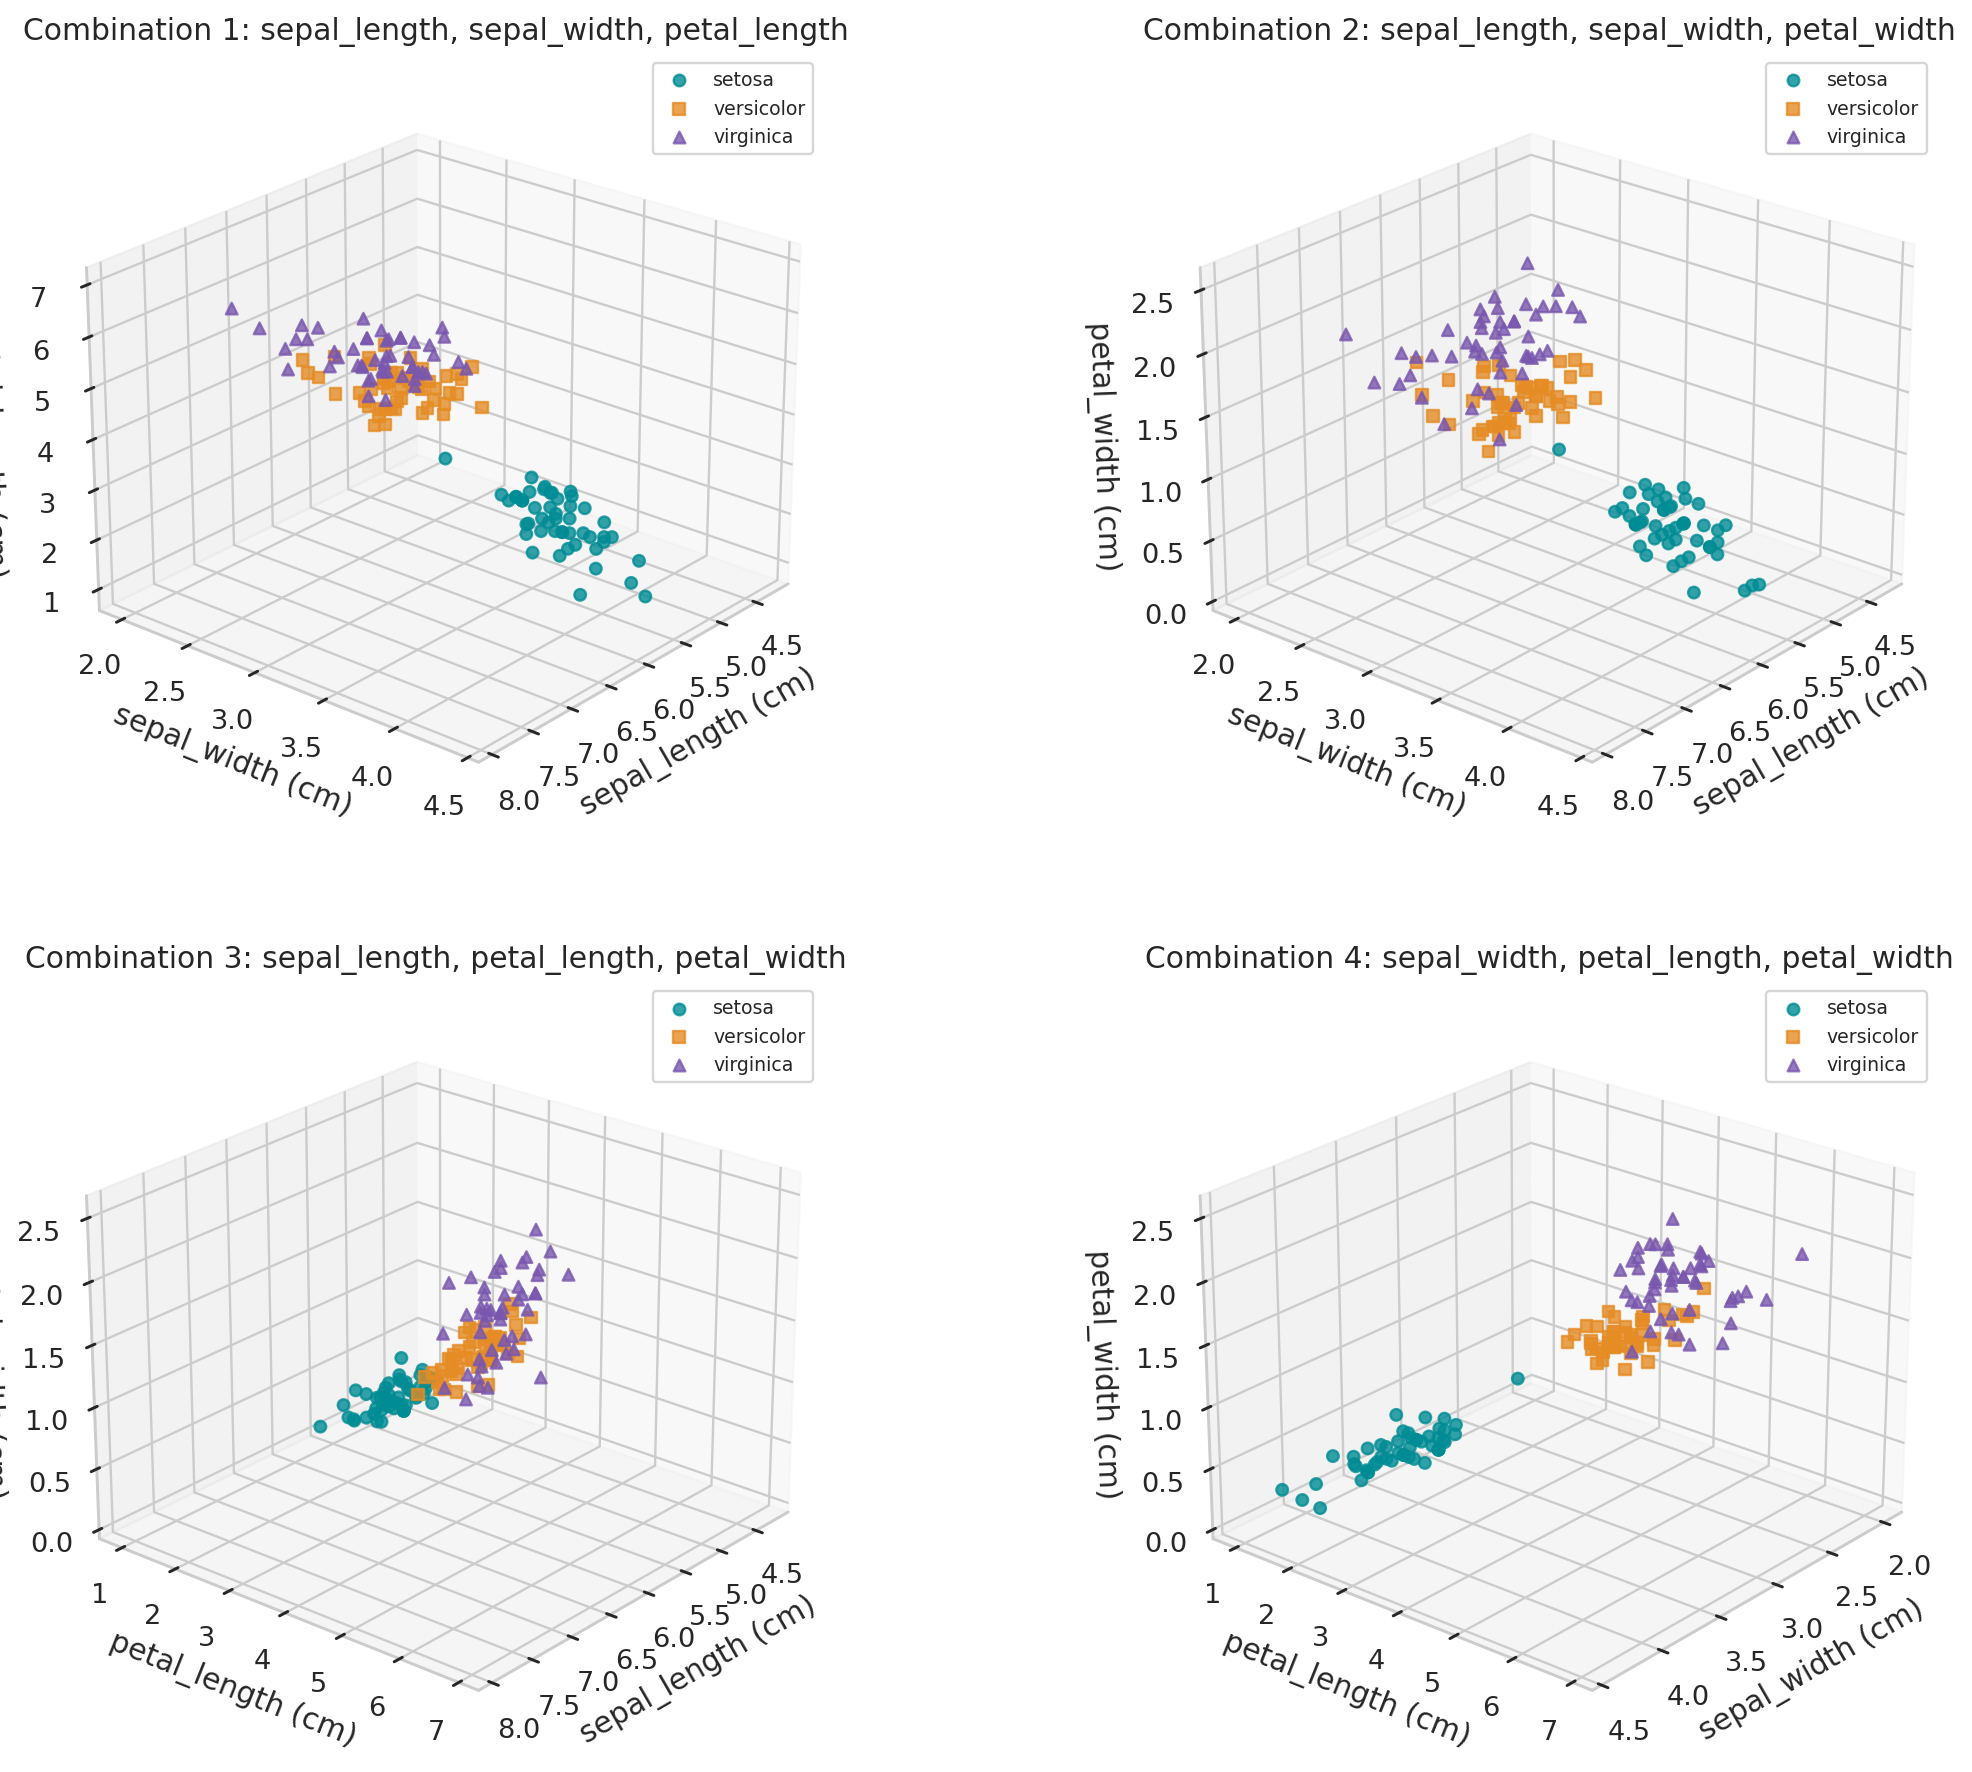

*Hình 4. Đủ bốn tổ hợp ba chiều; cùng góc nhìn và quy ước màu.*

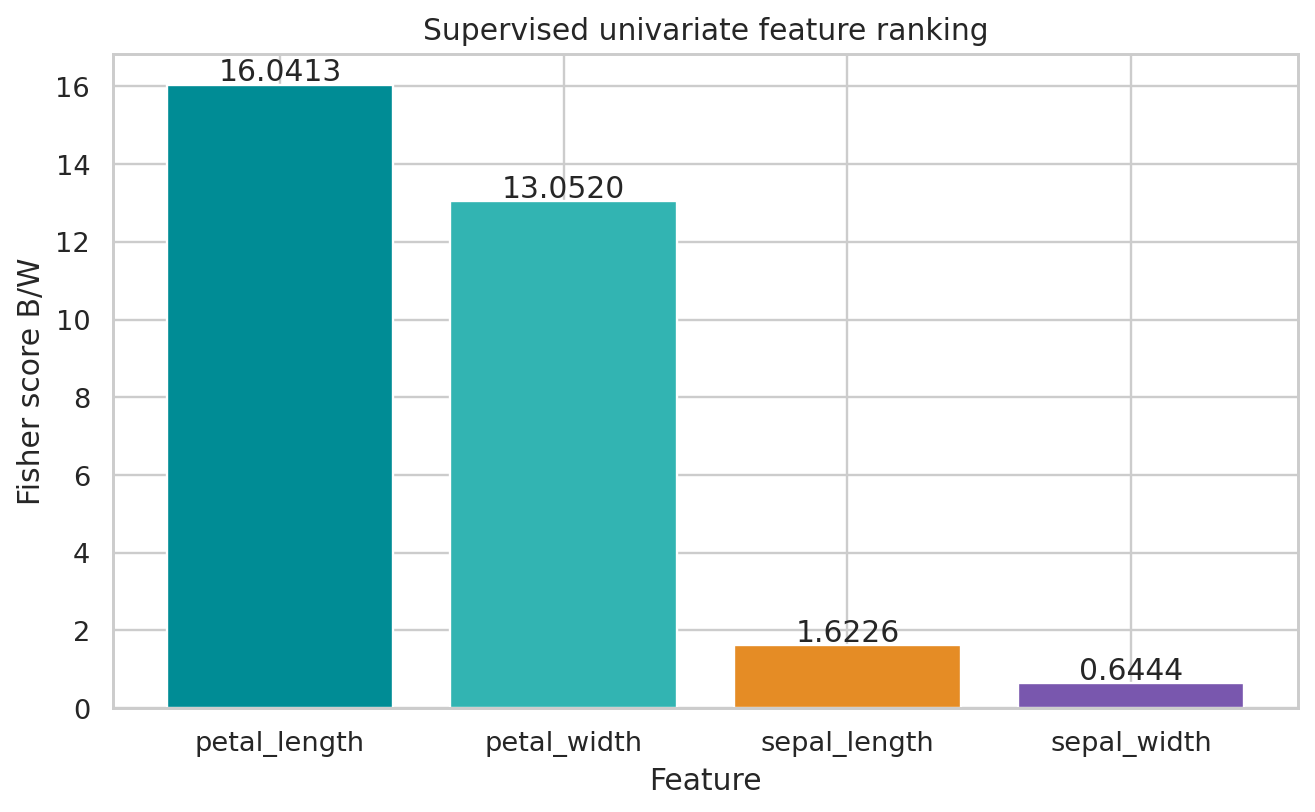

*Hình 5. Thứ hạng Fisher theo định nghĩa B/W.*

| Hạng tham khảo 2D | Cặp đặc trưng | Nhận xét hình học |
|---|---|---|
|1|petal_length + petal_width|Setosa tách rõ; hai lớp còn lại tương đối tập trung nhưng vẫn giao nhau|
|2–3, đồng hạng định tính|sepal_length + petal_width; sepal_width + petal_width|Petal width tạo phần lớn độ tách lớp; trục sepal bổ sung hình dạng cụm|
|4–5, đồng hạng định tính|sepal_length + petal_length; sepal_width + petal_length|Petal length tách setosa tốt; versicolor và virginica còn giao nhau|
|6|sepal_length + sepal_width|Miền chồng lấn lớn hơn, đặc biệt giữa hai lớp không phải setosa|

Thứ hạng giữa các cặp trung gian chỉ là đánh giá trực quan trên hình, không phải thứ hạng hiệu năng đã kiểm định. Không có một thước đo định lượng cấp cặp nào được tính ở đây. Cặp petal được chọn theo tiêu chí rõ ràng: hai Fisher đơn biến cao nhất, đồng thời biểu đồ xác nhận khả năng biểu diễn ba lớp tốt.

| Bộ ba | Đánh giá |
|---|---|
|sepal_length, sepal_width, petal_length|Petal length giúp tách setosa; hai trục sepal thể hiện biến thiên bổ sung|
|sepal_length, sepal_width, petal_width|Petal width cung cấp chiều phân biệt quan trọng; hai lớp còn lại chưa tách tuyệt đối|
|sepal_length, petal_length, petal_width|Bộ ba được đề xuất theo top-3 Fisher; chứa cả hai thuộc tính petal mạnh nhất|
|sepal_width, petal_length, petal_width|Cũng biểu diễn tốt; sepal width thêm hướng biến thiên khác dù Fisher thấp|

Bộ ba sepal length–petal length–petal width là lựa chọn theo top-3 Fisher, không phải tuyên bố tối ưu toàn cục. Trục thứ ba bổ sung thông tin nhưng hình 3D có thể che khuất điểm và phụ thuộc góc nhìn. Với mục tiêu thuyết trình đơn giản, cặp petal đã thể hiện cấu trúc lớp rõ ràng; chưa có bằng chứng thực nghiệm rằng thêm trục thứ ba cải thiện phân loại ngoài mẫu.

Fisher và hình học thống nhất ở vai trò nổi bật của các đặc trưng petal. Tuy nhiên, điểm Fisher cao của từng cột không đảm bảo tập hợp hai cột là tối ưu: Pearson giữa chúng bằng 0,9628, nên có nhiều thông tin lặp lại. Nếu mục tiêu là mô hình dự đoán, cần so sánh các cặp bằng validation trong pipeline, có thể cân nhắc độ dư thừa và tính bổ sung. Không được suy ra độ chính xác 100% từ hình phân cụm.



# PHẦN 3 — FEATURE EXTRACTION: PCA
## Bước 1. Lý thuyết và công thức

PCA tạo các trục mới là tổ hợp tuyến tính của đặc trưng. Chuẩn hóa bắt buộc trước PCA để mỗi cột có phương sai 1, tránh để đơn vị đo hoặc độ phân tán ban đầu chi phối mục tiêu. Trong báo cáo này:

$$z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\qquad Z\in\mathbb{R}^{150\times4}.$$

PCA tiếp tục trừ trung bình của $Z$ (gần bằng 0 do sai số số học), rồi lập ma trận hiệp phương sai:

$$\widetilde Z=Z-\mathbf{1}\bar{\mathbf z}^{\top},\qquad S=\frac{\widetilde Z^{\top}\widetilde Z}{n-1},\qquad S\mathbf v_k=\lambda_k\mathbf v_k.$$

Các eigenvector trực chuẩn được sắp theo $\lambda_1\ge\cdots\ge\lambda_4$. Điểm chiếu là $T_k=\widetilde ZV_k$, với $V_k=[\mathbf v_1,\ldots,\mathbf v_k]$. PC1 tối đa hóa phương sai phép chiếu; các PC tiếp theo tối đa hóa phần phương sai còn lại dưới ràng buộc trực giao.

$$EVR_k=\frac{\lambda_k}{\sum_{j=1}^4\lambda_j},\qquad CE_k=\sum_{j=1}^{k}EVR_j,\qquad k^*=\min\{k:CE_k\ge0.95\}.$$

Vì StandardScaler dùng mẫu số $n$ còn covariance PCA dùng $n-1$, tổng eigenvalue là $4n/(n-1)=4.026846$, không đúng bằng 4. Tỷ lệ phương sai không bị ảnh hưởng bởi hệ số chung này. PCA tối ưu tái tạo theo sai số bình phương trong không gian đã chuẩn hóa; 95% phương sai không có nghĩa 95% độ chính xác phân loại.

## Bước 2. Ví dụ tính thủ công

Với sepal length mẫu 0, cần đổi Std mẫu 0,828066 sang đúng Std của StandardScaler:

$$\sigma_{SL}=0.828066\sqrt{149/150}=0.825301,$$
$$z_{0,SL}=(5.1-5.843333)/0.825301=-0.900681.$$

Nếu chia trực tiếp cho 0,828066, kết quả là -0,897674: đây là chuẩn hóa theo Std mẫu, không phải giá trị StandardScaler. Tính tương tự cho cả bốn cột:

$$\mathbf z_0=(-0.900681,\ 1.032057,\ -1.341272,\ -1.312977).$$

Các trọng số PC1 và PC2 lấy từ nghiệm riêng trên toàn tập; không thể suy ra các eigenvector từ một dòng dữ liệu. Quy ước dấu: hệ số có trị tuyệt đối lớn nhất trên mỗi PC được đặt dương.

$$\mathbf v_1=(0.522372,-0.263355,0.581254,0.565611),$$
$$\mathbf v_2=(0.372318,0.925556,0.021095,0.065416).$$

Thay số để chiếu mẫu 0:

$$PC1_0=(-0.900681)(0.522372)+(1.032057)(-0.263355)+(-1.341272)(0.581254)+(-1.312977)(0.565611)=-2.264542,$$
$$PC2_0=(-0.900681)(0.372318)+(1.032057)(0.925556)+(-1.341272)(0.021095)+(-1.312977)(0.065416)=0.505704.$$

Từ eigenvalue $\lambda_1=2.930354$, tính $EVR_1=2.930354/4.026846\approx0.727705$. Một PC giữ 72,7705%, chưa đủ 95%; thêm PC2 được $72.7705\%+23.0305\%=95.8010\%$, nên giữ hai chiều. Kết quả phép nhân dùng hệ số đầy đủ; số đã làm tròn có thể lệch vài đơn vị ở chữ số thập phân cuối.

## Bước 3. Mã Python chạy độc lập



In [ ]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Chạy từ file .py hoặc cell Jupyter trong thư mục dự án.
if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data/raw/iris.data").exists())
FIG = ROOT / "figures"
TAB = ROOT / "tables"
FIG.mkdir(exist_ok=True)
TAB.mkdir(exist_ok=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df = pd.read_csv(ROOT / "data/raw/iris.data", header=None,
                 names=FEATURES + ["species"])
X, y = df[FEATURES].astype(float), df["species"]
assert X.shape == (150, 4) and not df.isna().any().any()
assert y.value_counts().eq(50).all()
CLASSES = sorted(y.unique())
COLORS = ["#008c95", "#e58c25", "#7957ae"]
MARKERS = ["o", "s", "^"]
sns.set_theme(style="whitegrid", font_scale=1.05)

def save_table(frame, name):
    frame.to_csv(TAB / (name + ".csv"), encoding="utf-8-sig")
    print("\n" + name + "\n" + frame.round(6).to_string())

def save_fig(fig, name):
    fig.savefig(FIG / (name + ".png"), dpi=170, bbox_inches="tight")
    plt.close(fig)

def scatter(ax, data, a, b, unit="cm"):
    for cls, color, marker in zip(CLASSES, COLORS, MARKERS):
        m = y == cls
        ax.scatter(data.loc[m, a], data.loc[m, b], c=color, marker=marker,
                   label=cls.replace("Iris-", ""), alpha=.8, s=32)
    suffix = f" ({unit})" if unit else ""
    ax.set(xlabel=a + suffix, ylabel=b + suffix)
    ax.legend(fontsize=8)

# PHẦN 3: bắt buộc chuẩn hóa trước PCA; full SVD giúp tái lập rõ ràng.
scaler = StandardScaler()
Z = scaler.fit_transform(X)
pca = PCA(svd_solver="full")
T = pca.fit_transform(Z)
# Cố định dấu: hệ số có trị tuyệt đối lớn nhất trên mỗi PC là dương.
# Đảo dấu không thay đổi phương sai hay hình học.
for j in range(4):
    if pca.components_[j,np.argmax(np.abs(pca.components_[j]))] < 0:
        pca.components_[j] *= -1
        T[:,j] *= -1
pcs = ["PC1","PC2","PC3","PC4"]
evr = pca.explained_variance_ratio_
k = int(np.searchsorted(np.cumsum(evr),.95)+1)
save_table(pd.DataFrame({"eigenvalue":pca.explained_variance_,"variance_ratio":evr,
                        "cumulative_ratio":np.cumsum(evr)},index=pcs),"pca_variance")
save_table(pd.DataFrame(pca.components_.T,index=FEATURES,columns=pcs),"pca_weights")
save_table(pd.DataFrame(T,columns=pcs),"pca_scores")
save_table(pd.DataFrame(Z,columns=FEATURES),"standardized_X")
print("Components required for 95%:",k)
assert k==2
assert np.allclose(np.var(Z,axis=0),1)
assert np.allclose(T,Z @ pca.components_.T)
fig,ax=plt.subplots(figsize=(8,5))
ax.bar(range(1,5),evr*100,alpha=.6,label="Individual")
ax.plot(range(1,5),np.cumsum(evr)*100,"o-",label="Cumulative")
ax.axhline(95,color="red",ls="--",label="95% threshold")
ax.set(xticks=range(1,5),xlabel="Number of components",ylabel="Explained variance (%)",title="PCA after StandardScaler")
ax.legend();save_fig(fig,"06_pca_variance")
fig,ax=plt.subplots(figsize=(9,6))
scatter(ax,pd.DataFrame(T,columns=pcs),"PC1","PC2",unit="")
ax.set(xlabel=f"PC1 ({evr[0]:.2%})",ylabel=f"PC2 ({evr[1]:.2%})",title="Iris in PCA space | 95% energy retained")
save_fig(fig,"07_pca_scatter")




## Bước 4. Kết quả, trực quan hóa và nhận xét

| Index | eigenvalue | variance_ratio | cumulative_ratio |
|---|---|---|---|
| PC1 | 2.930354 | 0.727705 | 0.727705 |
| PC2 | 0.927404 | 0.230305 | 0.958010 |
| PC3 | 0.148342 | 0.036838 | 0.994848 |
| PC4 | 0.020746 | 0.005152 | 1.000000 |

Ma trận trọng số (eigenvector, không phải hệ số tương quan feature–PC):

| Index | PC1 | PC2 | PC3 | PC4 |
|---|---|---|---|---|
| sepal_length | 0.522372 | 0.372318 | 0.721017 | -0.261996 |
| sepal_width | -0.263355 | 0.925556 | -0.242033 | 0.124135 |
| petal_length | 0.581254 | 0.021095 | -0.140892 | 0.801154 |
| petal_width | 0.565611 | 0.065416 | -0.633801 | -0.523546 |
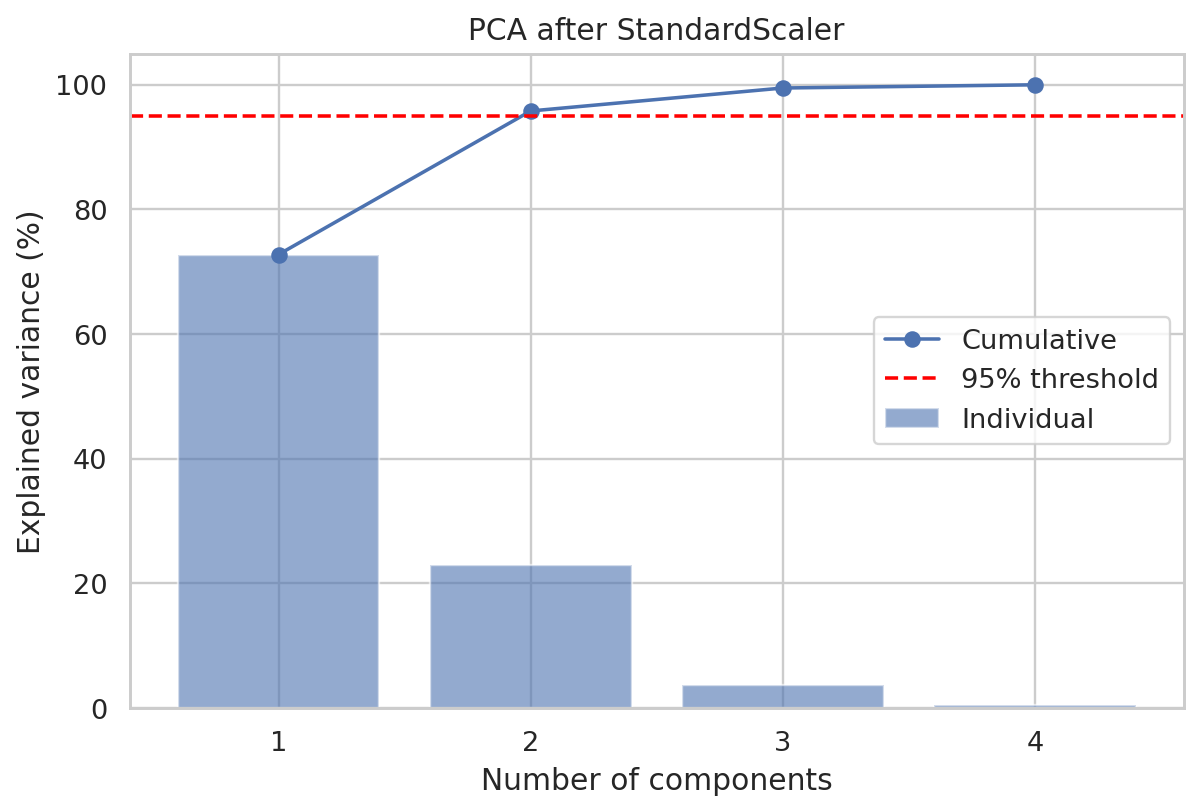

*Hình 6. Phương sai riêng, tích lũy và ngưỡng năng lượng 95%.*

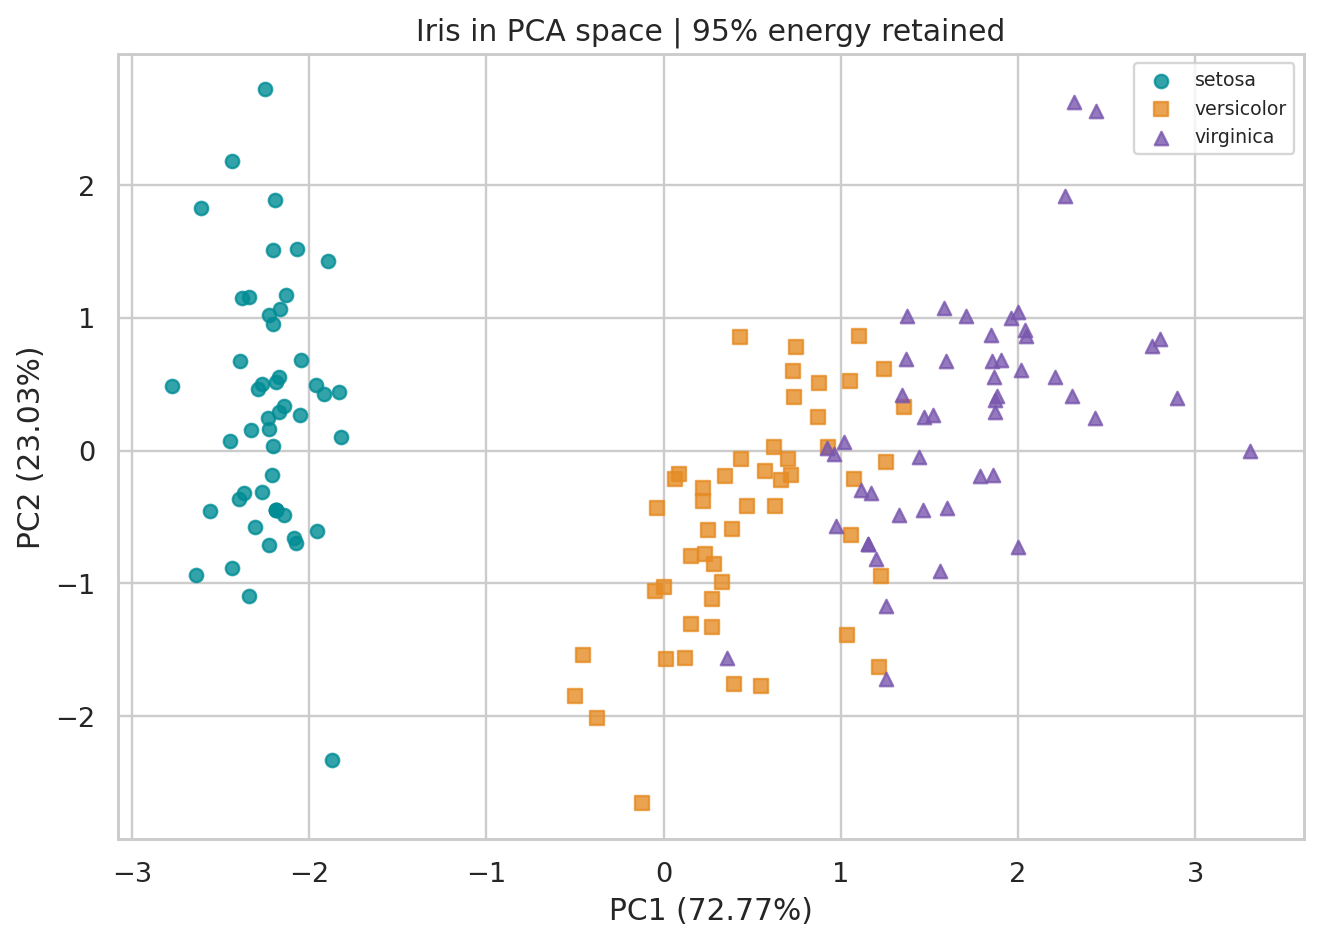

*Hình 7. Điểm chiếu lên PC1–PC2; nhãn chỉ dùng để tô màu sau khi fit PCA.*

PC1 kết hợp dương sepal length và hai đặc trưng petal, với trọng số âm của sepal width. Theo chiều tăng PC1, dữ liệu có xu hướng đi từ setosa sang các loài có cánh hoa lớn hơn. PC2 chủ yếu gắn với sepal width (0,9256), mô tả một hướng biến thiên đáng kể mà Fisher đơn biến đánh giá kém về tách lớp. Đây là minh họa trực tiếp cho khác biệt giữa “nhiều phương sai” và “nhiều thông tin phân loại”.

Setosa tách rõ trong không gian PCA; versicolor và virginica còn giao nhau. Dấu PC có thể đảo trên phiên bản thư viện hoặc solver khác; nếu toàn bộ trục và tọa độ cùng đổi dấu thì hình chỉ bị phản chiếu, không làm thay đổi EVR, khoảng cách hay chất lượng biểu diễn. Code cố định dấu để phép tính tay và hình nhất quán.

| Tiêu chí | Fisher feature selection | PCA feature extraction |
|---|---|---|
|Dữ liệu dùng khi fit|$X$ và $y$|Chỉ $X$; $y$ dùng để tô màu|
|Mục tiêu|Tăng độ khác biệt giữa lớp so với nội lớp của từng feature|Tối đa hóa phương sai giữ lại / giảm sai số tái tạo|
|Biến đổi $d\to k$|$150\times4\to150\times2$ bằng chọn cột PL, PW|$150\times4\to150\times2$ bằng chuẩn hóa rồi nhân $V_2$|
|Đầu ra|Hai số đo vật lý còn đơn vị cm|Hai tổ hợp tuyến tính không còn đơn vị cm|
|Diễn giải|Dễ giải thích trực tiếp bằng kích thước cánh hoa|Cần đọc các trọng số để hiểu mỗi trục|
|Dư thừa tuyến tính|Có thể còn cao; cặp chọn có $r=0.9628$|Các PC không tương quan trên tập fit|
|Thông tin bị bỏ|Toàn bộ các cột không chọn|Các hướng PC3, PC4, tương ứng 4,1990% phương sai chuẩn hóa|
|Giới hạn|Xếp hạng đơn biến không xét tương tác hoặc dư thừa theo tập|Không bảo đảm giữ hướng phân biệt lớp tốt nhất|

Chọn Fisher khi cần giữ ý nghĩa gốc và ưu tiên thông tin nhãn. Chọn PCA khi muốn nén biểu diễn hoặc xử lý dư thừa tuyến tính mà không dựa vào nhãn. PCA không làm cho các PC độc lập thống kê nói chung; trực giao và covariance bằng 0 chỉ bảo đảm không tương quan tuyến tính. Không so sánh tỷ lệ 95,8010% của PCA với điểm Fisher như hai đại lượng cùng đơn vị.



# PHẦN 4 — DATA NORMALIZATION
## Bước 1. Lý thuyết và công thức

Min–Max chuyển mỗi cột về đoạn [0,1] dựa trên cực trị của tập fit:

$$x'_{ij}=\frac{x_{ij}-a_j}{b_j-a_j},\qquad a_j=\min_i x_{ij},\quad b_j=\max_i x_{ij}.$$

Z-score dịch trung bình về 0 và chia cho độ lệch chuẩn:

$$z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\qquad \sigma_j=\sqrt{\frac1n\sum_i(x_{ij}-\mu_j)^2}.$$

Các cột Iris đều có range và Std khác 0. Với phép biến đổi affine $u=ax+b$, $a>0$, ta có $\mu_u=a\mu_x+b$, $\sigma_u=a\sigma_x$, thứ tự điểm được bảo toàn, và Pearson giữa hai cột cũng được bảo toàn khi mỗi cột được biến đổi với hệ số dương. Tuy vậy, việc co giãn khác nhau theo các trục thay đổi khoảng cách Euclid và góc trong hệ tọa độ mới.

Min–Max không bảo đảm dữ liệu tương lai nằm trong [0,1] khi ngoài cực trị tập fit. Z-score không có giới hạn cứng và không buộc dữ liệu trở thành phân phối chuẩn. Cả hai đều nhạy với ngoại lệ theo những cách khác nhau: Min–Max chịu ảnh hưởng trực tiếp của cực trị; Z-score phụ thuộc mean và Std.

## Bước 2. Ví dụ tính thủ công

Mẫu 0 có petal length 1,4 cm và petal width 0,2 cm. Chuẩn hóa Min–Max:

$$PL'_0=(1.4-1.0)/(6.9-1.0)=0.4/5.9=0.067797,$$
$$PW'_0=(0.2-0.1)/(2.5-0.1)=0.1/2.4=0.041667.$$

Chuẩn hóa Z-score theo `ddof=0`:

$$z_{0,PL}=(1.4-3.758667)/1.758529=-1.341272,$$
$$z_{0,PW}=(0.2-1.198667)/0.760613=-1.312977.$$

Để đối chiếu với thông số sepal length nêu trong yêu cầu:

$$SL'_0=(5.1-4.3)/(7.9-4.3)=0.222222,\qquad z_{0,SL}=-0.900681.$$

Có thể dự đoán thống kê Min–Max mà không cần tính lại từng dòng: $\mu'_{PL}=(3.758667-1)/5.9=0.467571$ và $\sigma'_{PL}=1.758529/5.9=0.298056$. Z-score sẽ có mean gần 0, Std `ddof=0` bằng 1; nếu dùng `ddof=1` sau biến đổi, Std bằng $\sqrt{150/149}=1.003350$, không phải lỗi phần mềm.

## Bước 3. Mã Python chạy độc lập



In [ ]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Chạy từ file .py hoặc cell Jupyter trong thư mục dự án.
if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "data/raw/iris.data").exists())
FIG = ROOT / "figures"
TAB = ROOT / "tables"
FIG.mkdir(exist_ok=True)
TAB.mkdir(exist_ok=True)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df = pd.read_csv(ROOT / "data/raw/iris.data", header=None,
                 names=FEATURES + ["species"])
X, y = df[FEATURES].astype(float), df["species"]
assert X.shape == (150, 4) and not df.isna().any().any()
assert y.value_counts().eq(50).all()
CLASSES = sorted(y.unique())
COLORS = ["#008c95", "#e58c25", "#7957ae"]
MARKERS = ["o", "s", "^"]
sns.set_theme(style="whitegrid", font_scale=1.05)

def save_table(frame, name):
    frame.to_csv(TAB / (name + ".csv"), encoding="utf-8-sig")
    print("\n" + name + "\n" + frame.round(6).to_string())

def save_fig(fig, name):
    fig.savefig(FIG / (name + ".png"), dpi=170, bbox_inches="tight")
    plt.close(fig)

def scatter(ax, data, a, b, unit="cm"):
    for cls, color, marker in zip(CLASSES, COLORS, MARKERS):
        m = y == cls
        ax.scatter(data.loc[m, a], data.loc[m, b], c=color, marker=marker,
                   label=cls.replace("Iris-", ""), alpha=.8, s=32)
    suffix = f" ({unit})" if unit else ""
    ax.set(xlabel=a + suffix, ylabel=b + suffix)
    ax.legend(fontsize=8)

# PHẦN 4: chuẩn hóa toàn bộ 4 feature theo PDF; vẽ cặp tốt nhất.
selected=["petal_length","petal_width"]
mm=pd.DataFrame(MinMaxScaler().fit_transform(X),columns=FEATURES)
zs=pd.DataFrame(StandardScaler().fit_transform(X),columns=FEATURES)
versions={"Original":X,"MinMax":mm,"Zscore":zs}
rows=[]
for method,data in versions.items():
    save_table(data,method.lower()+"_features")
    for f in FEATURES:
        rows.append([method,f,data[f].min(),data[f].max(),data[f].mean(),data[f].std(ddof=0),data[f].std(ddof=1)])
stats=pd.DataFrame(rows,columns=["method","feature","min","max","mean","std_ddof0","std_ddof1"])
save_table(stats,"normalization_statistics")
fig,axes=plt.subplots(1,3,figsize=(17,5))
for ax,(method,data) in zip(axes,versions.items()):
    scatter(ax,data,*selected,unit="cm" if method=="Original" else "")
    ax.set_title(method)
fig.tight_layout();save_fig(fig,"08_normalization_scatter")
# Giữ cùng số bin, các biên tự co giãn theo biến đổi affine.
fig,axes=plt.subplots(2,3,figsize=(16,9))
for j,(method,data) in enumerate(versions.items()):
    for i,f in enumerate(selected):
        original_bins=np.linspace(X[f].min(),X[f].max(),16)
        # Tính membership bin trên dữ liệu gốc một lần để tránh sai số
        # floating-point ở các điểm trùng biên sau biến đổi affine.
        bins=np.linspace(data[f].min(),data[f].max(),16)
        for cls,col in zip(CLASSES,COLORS):
            counts,_=np.histogram(X.loc[y==cls,f],bins=original_bins)
            axes[i,j].bar((bins[:-1]+bins[1:])/2,counts,width=np.diff(bins),
                          alpha=.5,label=cls.replace("Iris-",""),color=col)
        axes[i,j].set(title=method+" | "+f,xlabel=f+(" (cm)" if method=="Original" else ""),ylabel="Count")
        axes[i,j].legend(fontsize=8)
fig.tight_layout();save_fig(fig,"09_normalization_distributions")
assert np.allclose(mm.min(),0) and np.allclose(mm.max(),1)
assert np.allclose(zs.mean(),0,atol=1e-12) and np.allclose(zs.std(ddof=0),1)
assert np.allclose(X.corr(),mm.corr()) and np.allclose(X.corr(),zs.corr())
print("Normalization and correlation checks passed.")




## Bước 4. Kết quả, trực quan hóa và nhận xét

Bảng so sánh cả bốn đặc trưng trước và sau; số rất gần 0 do sai số máy được làm tròn thành 0:

| Index | method | feature | min | max | mean | std_ddof0 | std_ddof1 |
|---|---|---|---|---|---|---|---|
| 0 | Original | sepal_length | 4.300000 | 7.900000 | 5.843333 | 0.825301 | 0.828066 |
| 1 | Original | sepal_width | 2.000000 | 4.400000 | 3.054000 | 0.432147 | 0.433594 |
| 2 | Original | petal_length | 1.000000 | 6.900000 | 3.758667 | 1.758529 | 1.764420 |
| 3 | Original | petal_width | 0.100000 | 2.500000 | 1.198667 | 0.760613 | 0.763161 |
| 4 | MinMax | sepal_length | 0.000000 | 1.000000 | 0.428704 | 0.229250 | 0.230018 |
| 5 | MinMax | sepal_width | 0.000000 | 1.000000 | 0.439167 | 0.180061 | 0.180664 |
| 6 | MinMax | petal_length | 0.000000 | 1.000000 | 0.467571 | 0.298056 | 0.299054 |
| 7 | MinMax | petal_width | 0.000000 | 1.000000 | 0.457778 | 0.316922 | 0.317984 |
| 8 | Zscore | sepal_length | -1.870024 | 2.492019 | -0.000000 | 1.000000 | 1.003350 |
| 9 | Zscore | sepal_width | -2.438987 | 3.114684 | -0.000000 | 1.000000 | 1.003350 |
| 10 | Zscore | petal_length | -1.568735 | 1.786341 | 0.000000 | 1.000000 | 1.003350 |
| 11 | Zscore | petal_width | -1.444450 | 1.710902 | -0.000000 | 1.000000 | 1.003350 |
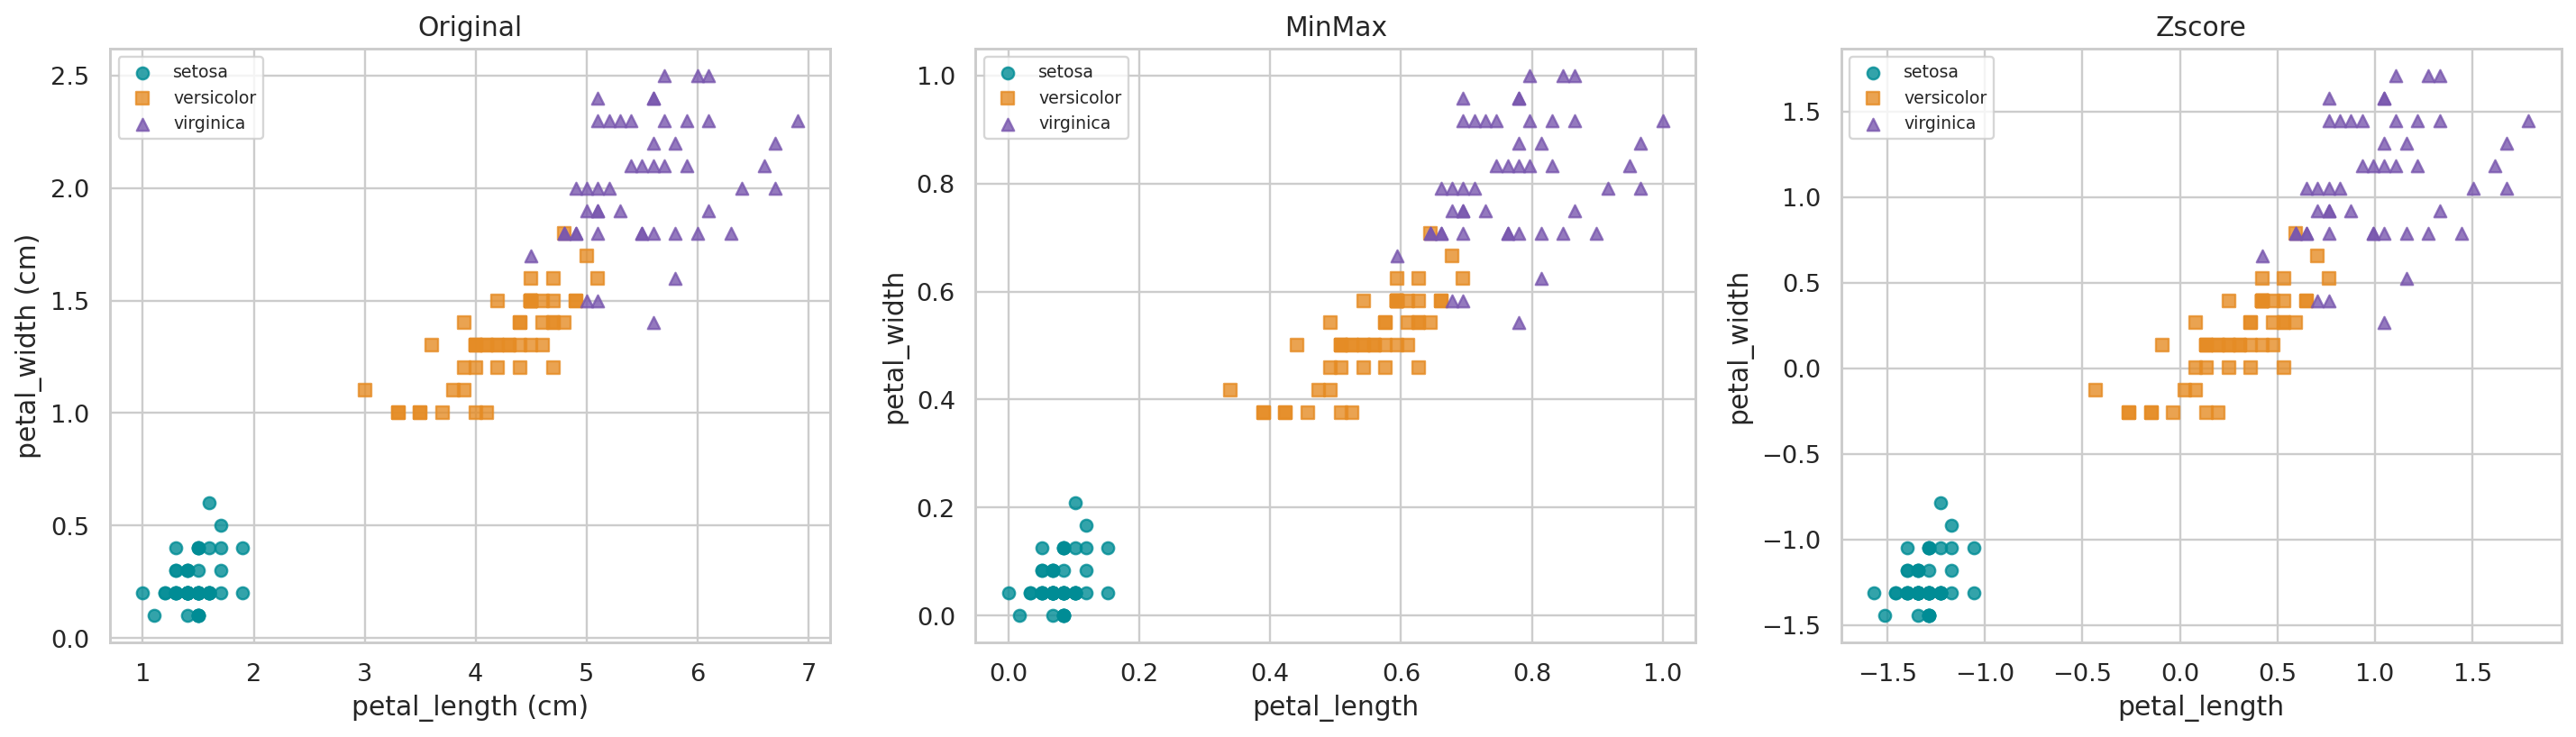

*Hình 8. Cùng cặp petal length–petal width ở thang gốc, Min–Max và Z-score.*

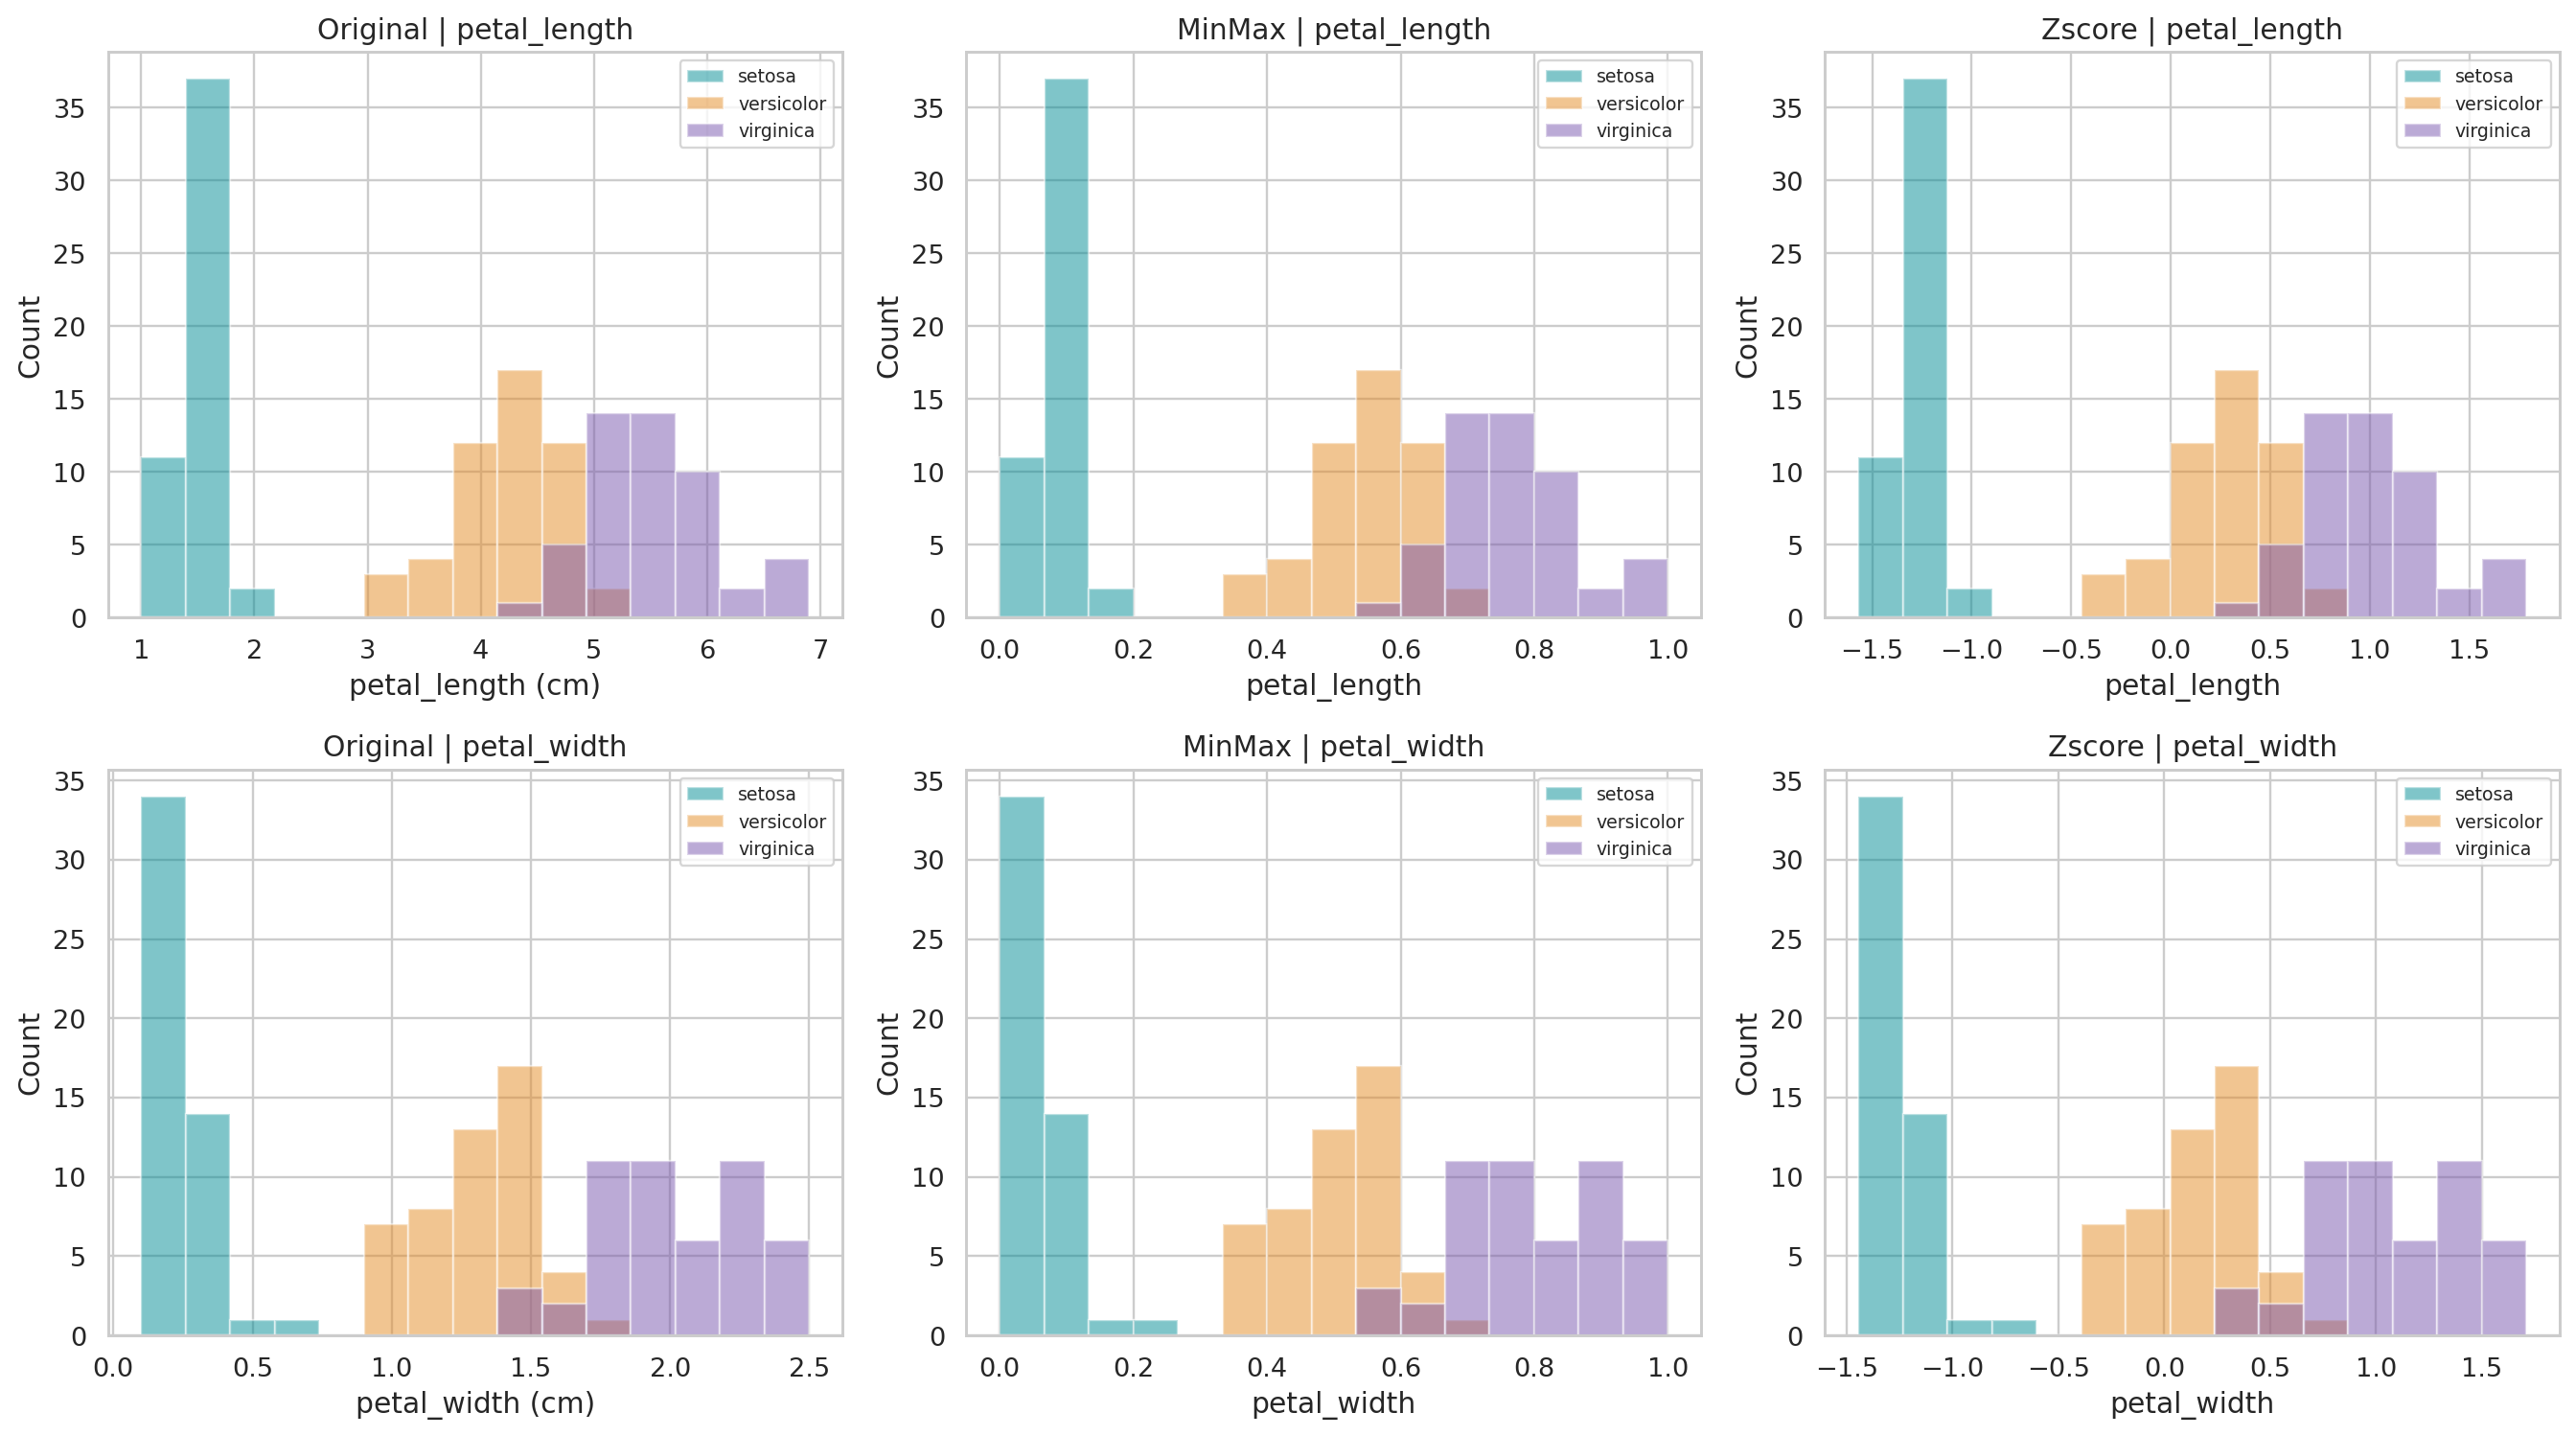

*Hình 9. Histogram theo lớp; cùng số bin với biên được biến đổi tương ứng.*

| Sample index 0 | Original (cm) | Min–Max | Z-score |
|---|---:|---:|---:|
|petal_length|1.4|0.067797|-1.341272|
|petal_width|0.2|0.041667|-1.312977|

Ở dữ liệu gốc, petal length nằm trong [1,0; 6,9] cm và petal width nằm trong [0,1; 2,5] cm. Sau Min–Max, cả hai có range [0; 1] nhưng không cùng mean hay Std. Sau Z-score, chúng có mean 0 và Std 1 theo `ddof=0`, nhưng cực trị khác nhau: Z-score không ép mọi cột vào cùng một đoạn hữu hạn cố định.

Cấu trúc các cụm vẫn tương ứng một-một. Min–Max và Z-score là phép đổi tọa độ khả nghịch đối với các cột không hằng, nên không tự xóa chồng lấn và không tạo thêm thông tin phân loại. Hình có thể trông gần giống nhau do từng subplot tự điều chỉnh giới hạn trục; cần đọc trị số trên trục để hiểu phép biến đổi. Nếu áp đặt cùng đơn vị độ dài hiển thị, độ kéo giãn hình học giữa các trục sẽ rõ hơn.

Histogram giữ cấu trúc nhiều cụm và dạng phân bố dưới phép dịch–co giãn. Tần số mỗi bin không đổi khi dùng biên bin được chuyển đổi tương ứng; nếu vẽ mật độ, chiều cao density phải đổi để diện tích luôn bằng 1. Z-score không xóa tính đa đỉnh của dữ liệu trộn ba loài và không biến ba cụm thành một phân phối Gaussian.

Pearson của cặp petal vẫn là 0,962757 trong cả ba trường hợp. Fisher B/W từng cột cũng bất biến trước phép affine khác hằng vì tử và mẫu cùng nhân với bình phương hệ số co giãn. Ngược lại, các thuật toán dựa trên khoảng cách có thể thay đổi kết quả vì tỷ lệ đóng góp tương đối giữa các cột đã thay đổi.

# KẾT LUẬN VÀ HƯỚNG THUYẾT TRÌNH

Phân tích trên iris.data cho thấy hai đặc trưng petal là lựa chọn trực quan dễ diễn giải, với Fisher B/W lần lượt 16,041283 và 13,052033. Tuy nhiên, Pearson 0,962757 cảnh báo tính dư thừa. PCA sau StandardScaler nén bốn chiều thành hai chiều và giữ 95,8010% phương sai; trục PC2 cho thấy sepal width vẫn có vai trò quan trọng về biến thiên dù không đứng cao trong Fisher. Hai cách chuẩn hóa đổi thang đo, giữ cấu trúc phân bố theo phép affine, nhưng không giải quyết trực tiếp sự chồng lấn lớp.

Khi phát triển thành bài toán dự đoán, phải chia train/test trước và chỉ fit scaler, Fisher selection hoặc PCA trên phần training. Trong cross-validation, mọi bước fit phải nằm trong từng fold. Không dùng mean, cực trị, eigenvector hoặc điểm Fisher từ toàn bộ dữ liệu để xử lý một test set được gọi là độc lập. Báo cáo hiện tại là EDA trên toàn tập theo đề bài, chưa đo khả năng tổng quát hóa.

| Trình tự thuyết trình | Nội dung cốt lõi | Bằng chứng để trình chiếu |
|---|---|---|
|1|Bài toán, cấu trúc dữ liệu và phiên bản dùng|Bảng đặc trưng, 150 mẫu / 3 lớp|
|2|Mean, Std mẫu và Std theo StandardScaler|Phép tính sepal length của mẫu 0|
|3|Tương quan và đa cộng tuyến|Pairplot, heatmap, phép tính Pearson|
|4|Tất cả các lựa chọn 2D / 3D|Hình 3–4 và bảng xếp hạng định tính|
|5|Lựa chọn bằng nhãn|Fisher: công thức, tính tay, bảng và bar chart|
|6|PCA và điều kiện 95%|Chuẩn hóa, phép chiếu mẫu 0, EVR và PC scatter|
|7|Selection so với extraction|Bảng so sánh và ý nghĩa d → k|
|8|Đổi thang dữ liệu|Tính tay Min–Max, Z-score, bảng và hình trước/sau|
|9|Kết luận và giới hạn|Không nhầm variance với accuracy; tránh leakage|

# NGUỒN VÀ TÁI LẬP

| Nguồn | Vai trò |
|---|---|
|Bai_tap_Chuong_3_Data_Preprocessing_Iris.pdf, trang 1–2|Đề bài và các mục 1.1–4.3; bản gốc trong data/raw|
|iris.data; iris.names; bezdekIris.data; Index|Dữ liệu thực thi, mô tả và đối chiếu phiên bản do người dùng cung cấp|
|[UCI Iris](https://archive.ics.uci.edu/dataset/53/iris)|Xác nhận nguồn gốc dữ liệu|
|[StandardScaler](https://scikit-learn.org/1.6/modules/generated/sklearn.preprocessing.StandardScaler.html)|Quy ước chuẩn hóa mean và Std ddof=0|
|[PCA](https://sklearn.org/stable/modules/generated/sklearn.decomposition.PCA.html)|Ý nghĩa components, explained variance và full SVD|

Công thức Fisher được định nghĩa trực tiếp trong báo cáo và thực thi bằng tổng bình phương để loại bỏ mơ hồ giữa B/W và ANOVA F. Mọi nhận xét số học được tính từ tệp địa phương đã chọn; nguồn web chỉ hỗ trợ xuất xứ và định nghĩa API. Các phiên bản thực thi thực tế được ghi trong environment.json; SHA-256 của dữ liệu gốc trong data_manifest.json giúp kiểm tra tính đồng nhất.

Chạy `python -m pip install -r requirements.txt`, sau đó `python src/run_all.py`. Bốn script tự sinh lại các bảng CSV và chín hình PNG. Notebook đi theo đúng nội dung báo cáo và chứa các hình nhúng, có thể mở để đọc ngay hoặc chạy lại từng phần. Báo cáo HTML là bản xem offline, các công thức dùng MathML và ảnh được nhúng trực tiếp; nên mở bằng trình duyệt hiện đại. Markdown là bản nguồn thuận tiện chỉnh sửa.
